Sourced from https://m2lines.github.io/L96_demo/notebooks/intro_ML_and_NNs.html

In [1]:
!nvidia-smi

Sat Apr 18 12:17:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:25:00.0 Off |                    0 |
| N/A   30C    P0             34W /  250W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [1]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model
)
from utility import (
    MStarPredictorConfig, normalize, real_units,
    reduce_dataset, compute_rmse, prepare_data
)

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json
from dataclasses import asdict

import pandas as pd
import matplotlib.pyplot as plt

# Ensuring reproducibility
random_state = 123
np.random.seed(random_state)
torch.manual_seed(random_state);
sklear_random_state = random_state

In [2]:
if torch.cuda.is_available():
    print("GPU is available.")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available. PyTorch is likely using the CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

GPU is available.
Number of GPUs: 1
Current GPU name: NVIDIA A100-PCIE-40GB
Using device: cuda


In [3]:
data_directory = '../m_star_dataset'
dataset_name = 'ePBL_paper_expanded_2283_corrected'
validation_dataset_name = 'ePBL_paper_validation_2283_corrected'
dataset_filename = f"{dataset_name}_features_and_targets_101sig_even_interp"
validation_dataset_filename = f"{validation_dataset_name}_features_and_targets_101sig_even_interp"
data = pd.read_csv(os.path.join(data_directory, f"{dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{validation_dataset_filename}.csv"))

In [4]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [5]:
drop_first_inertial_T = False

if drop_first_inertial_T:
    n_timesteps = np.load(f"ePBL_paper_expanded_2283_corrected_dataset_M_target_dropped_first_inertial_T_timesteps.npy")
    n_timesteps_val = np.load(f"ePBL_paper_validation_2283_corrected_dataset_M_target_dropped_first_inertial_T_timesteps.npy")
else:
    n_timesteps, n_timesteps_val = 479, 479  # TODO: make it not hard-coded

In [6]:
### CONFIG ###

predictor_name = "predictor_14"
predictor_dir = os.path.join("m_star_predictors", predictor_name)
os.makedirs(predictor_dir, exist_ok=True)
weights_save_path = os.path.join(predictor_dir, "weights.pt")

feature_names = data.keys()[1:]
feature_transforms = {"": ""}
target_name = "M"
target_transform = "log10"

n_neurons = 32
n_hidden_layers = 3
learning_rate = 1e-4
weight_decay = 5e-4
activation = "tanh"
n_epochs = 3000

loss = "mse_loss"

input_size = len(feature_names)

if activation == "tanh":
    activation_fn = torch.nn.Tanh()
elif activation == "relu":
    activation_fn = torch.nn.ReLU()

if loss == "mse_loss":
    loss_fn = torch.nn.MSELoss()

In [7]:
X, y = prepare_data(
    dataframe=data,
    feature_names=feature_names,
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform
)

X_val, y_val = prepare_data(
    dataframe=validation_data,
    feature_names=feature_names,
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform
)

In [8]:
print(X.shape, y.shape)
print(X_val.shape, y_val.shape)

torch.Size([1396440, 202]) torch.Size([1396440, 1])
torch.Size([93096, 202]) torch.Size([93096, 1])


In [9]:
train_batch_size = int(1396440 / 16)
test_batch_size = int(93096 / 2)
print(train_batch_size, test_batch_size)

87277 46548


In [10]:
X_mean = X.mean(dim=0)
X_std = X.std(dim=0)
y_mean = y.mean(dim=0)
y_std = y.std(dim=0)

X_train = normalize(data=X, mean=X_mean, std=X_std)
X_test = normalize(data=X_val, mean=X_mean, std=X_std)
y_train = normalize(data=y, mean=y_mean, std=y_std)
y_test = normalize(data=y_val, mean=y_mean, std=y_std)

input_size = len(X_std[X_std!=0])

train_dataset = Data.TensorDataset(X_train, y_train)
test_dataset = Data.TensorDataset(X_test, y_test)

train_loader = Data.DataLoader(dataset=train_dataset, batch_size=train_batch_size, shuffle=True, num_workers=8, pin_memory=True)
test_loader = Data.DataLoader(dataset=test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=8, pin_memory=True)

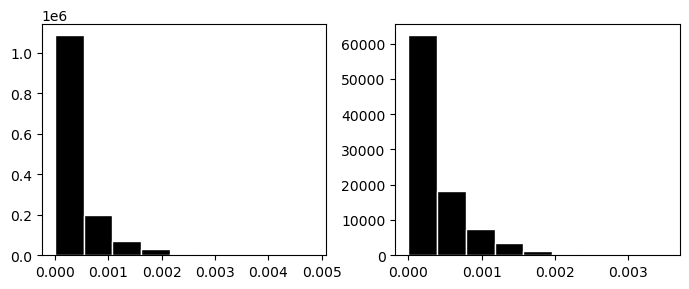

In [11]:
fig, ax = plt.subplots(1,2, figsize=(7,3))

i = 5

ax[0].hist(X[:,i].detach().numpy(), 9, color="black", ec="white")
ax[1].hist(X_val[:,i].detach().numpy(), 9, color="black", ec="white")

fig.tight_layout()

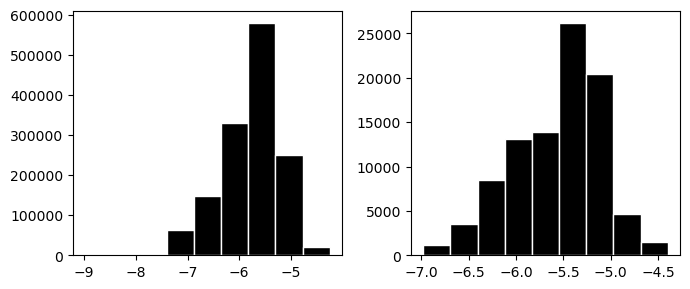

In [12]:
fig, ax = plt.subplots(1,2, figsize=(7,3))

ax[0].hist(y.detach().numpy(), 9, color="black", ec="white")
ax[1].hist(y_val.detach().numpy(), 9, color="black", ec="white")

fig.tight_layout()

In [ ]:
data_iterator = iter(train_loader)
X_iter, subgrid_tend_iter = next(data_iterator)

plt.plot(X_iter, subgrid_tend_iter, '.')

In [13]:
linear_network = LinearRegression(input_size=input_size)
fcnn_network = FCNN(input_size=input_size, n_hidden_layers=n_hidden_layers, n_neurons=n_neurons, activation=activation_fn)

In [14]:
optimizer_linear = optim.Adam(
    linear_network.parameters(), lr=5e-3, weight_decay=weight_decay
)
optimizer_fcnn = optim.Adam(
    fcnn_network.parameters(), lr=learning_rate, weight_decay=weight_decay
)

In [15]:
n_epochs_linear = 500
n_epochs_fcnn = n_epochs

In [18]:
for epoch, train_losses_linear, test_losses_linear in fit_model(linear_network, loss_fn, optimizer_linear, train_loader, test_loader, n_epochs_linear, device):
    pass

Epoch 1 completed. Train loss: 0.910212870906381; test loss: 0.6762050092220306.


Exception ignored in: <function _releaseLock at 0x150d2001edc0>
Traceback (most recent call last):
  File "/home/mm6851/miniconda3/envs/L96M2lines/lib/python3.9/logging/__init__.py", line 227, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 


Training completed in 6 seconds.


RuntimeError: DataLoader worker (pid(s) 731214, 731215, 731216, 731217) exited unexpectedly

In [ ]:
for epoch, train_losses, test_losses in fit_model(fcnn_network, loss_fn, optimizer_fcnn, train_loader, test_loader, n_epochs_fcnn, device):
    pass

Epoch 1 completed. Train loss: 1.0541526605101192; test loss: 0.9325601160526276.
Epoch 2 completed. Train loss: 0.9309415641952964; test loss: 0.9095722734928131.
Epoch 3 completed. Train loss: 0.9448353683247286; test loss: 0.8821416795253754.
Epoch 4 completed. Train loss: 0.8502369400332955; test loss: 0.8480896651744843.
Epoch 5 completed. Train loss: 0.844456763828502; test loss: 0.8146577477455139.
Epoch 6 completed. Train loss: 0.8215904411147622; test loss: 0.7731263041496277.
Epoch 7 completed. Train loss: 0.7652393859975478; test loss: 0.7282860279083252.
Epoch 8 completed. Train loss: 0.7795053545166465; test loss: 0.6723493337631226.
Epoch 9 completed. Train loss: 0.6944671097923728; test loss: 0.6257250308990479.
Epoch 10 completed. Train loss: 0.6605362085735097; test loss: 0.574550449848175.
Epoch 11 completed. Train loss: 0.6645601076238296; test loss: 0.5256451964378357.
Epoch 12 completed. Train loss: 0.5632978616391912; test loss: 0.4725741147994995.
Epoch 13 comple

In [21]:
train_losses

[1.056928582051221,
 0.9417787755236906,
 0.9611813075402204,
 0.869007045731825,
 0.8622230010874131,
 0.8379649905597463,
 0.7854138069293078,
 0.7971104313345516,
 0.7041390450561748,
 0.6687201962751501,
 0.6662000873509575,
 0.565244106685414,
 0.5203319402302012,
 0.4733206419383778,
 0.4509963200372808,
 0.3967299864572637,
 0.35944924898007335,
 0.32082365102627697,
 0.3140943383469301,
 0.2975069459746866,
 0.26240574349375334,
 0.24744092453928554,
 0.2319257460972842,
 0.21847614426823223,
 0.21923700237975402,
 0.21792580713244045,
 0.22395775598638198,
 0.2201465806540321,
 0.19548525266787586,
 0.2038017336060019,
 0.21255693803815282,
 0.19368427027674281,
 0.19521262014613433,
 0.1993018204675001,
 0.18082483331946766,
 0.19358781593687394,
 0.1925290016567006,
 0.18869072374175577,
 0.17605403942220352,
 0.17216566884342363,
 0.1693816292373573,
 0.17609054902020624,
 0.17348726882654078,
 0.17436906432404237,
 0.16709294301622055,
 0.1758336652727688,
 0.1704895075629

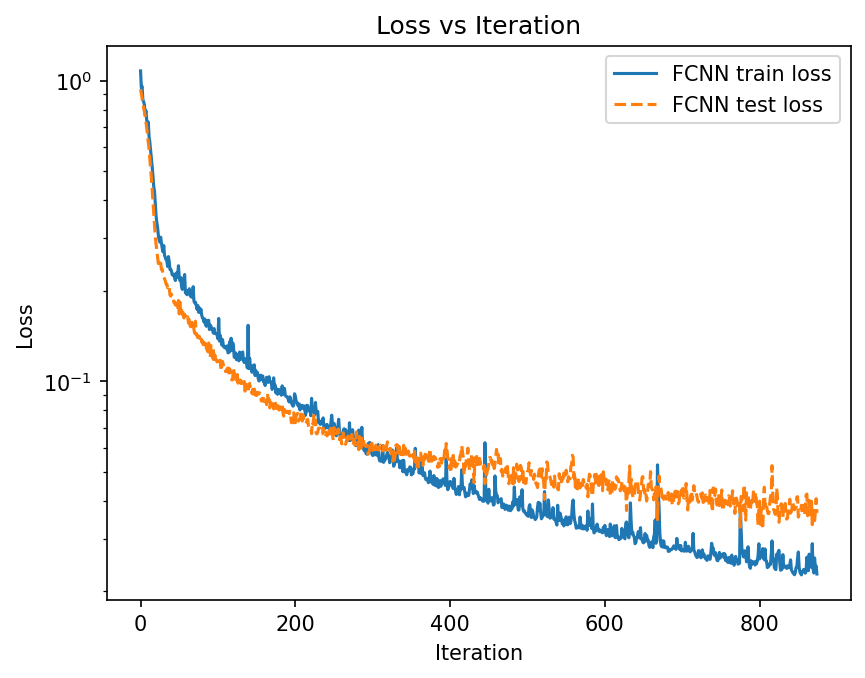

In [17]:
plt.figure(dpi=150)

# plt.plot(train_losses_linear, label="Linear train loss")
# plt.plot(test_losses_linear, linestyle="--", label="Linear test loss")

plt.plot(train_losses, label="FCNN train loss")
plt.plot(test_losses, linestyle="--", label="FCNN test loss")

plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.yscale("log")
plt.title("Loss vs Iteration")
plt.show();

In [18]:
torch.save(fcnn_network.state_dict(), weights_save_path)

In [19]:
if target_transform == "log10":
    fcnn_prediction_full = 10**real_units(normalized_data=fcnn_network(X_train.to(device)).cpu(), mean=y_mean, std=y_std)
    fcnn_val_prediction_full = 10**real_units(normalized_data=fcnn_network(X_test.to(device)).cpu(), mean=y_mean, std=y_std)
elif target_transform == "sqrt":
    fcnn_prediction_full = real_units(normalized_data=fcnn_network(X_train.to(device)).cpu(), mean=y_mean, std=y_std)**2
    fcnn_val_prediction_full = real_units(normalized_data=fcnn_network(X_test.to(device)).cpu(), mean=y_mean, std=y_std)**2
else:
    fcnn_prediction_full = real_units(normalized_data=fcnn_network(X_train.to(device)).cpu(), mean=y_mean, std=y_std)
    fcnn_val_prediction_full = real_units(normalized_data=fcnn_network(X_test.to(device)).cpu(), mean=y_mean, std=y_std)

In [20]:
rmse = compute_rmse(y_pred=fcnn_val_prediction_full, y_true=10**y_val)

In [21]:
rmse

tensor(1.1766e-06, grad_fn=<SqrtBackward0>)

In [23]:
config = MStarPredictorConfig(
    dataset_name=dataset_name,
    dataset_filename=dataset_filename,
    validation_dataset_name=validation_dataset_name,
    validation_dataset_filename=validation_dataset_filename,
    weights_save_path=weights_save_path,
    feature_names=feature_names.tolist(),
    feature_transforms=feature_transforms,
    target_name=target_name,
    target_transform=target_transform,
    n_neurons=n_neurons,
    n_hidden_layers=n_hidden_layers,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    activation=activation,
    loss=loss,
    n_epochs=epoch,
    random_state=random_state,
    train_batch_size=train_batch_size,
    test_batch_size=test_batch_size,
    feature_mean=X_mean.detach().numpy().tolist(),
    feature_std=X_std.detach().numpy().tolist(),
    target_mean=y_mean.detach().numpy().tolist(),
    target_std=y_std.detach().numpy().tolist(),
    train_loss_trajectory=train_losses,
    test_loss_trajectory=test_losses,
    n_time_steps=n_timesteps,
    n_time_steps_val=n_timesteps_val,
    rmse=rmse.item()
)

In [24]:
json_string = json.dumps(asdict(config))
json_save_path = os.path.join(predictor_dir, "config.json")

with open(json_save_path, "w") as f:
    json.dump(asdict(config), f)

In [32]:
linear_prediction_full = 10**real_units(normalized_data=linear_network(X_train.to(device)).cpu(), mean=y_mean, std=y_std)
linear_val_prediction_full = 10**real_units(normalized_data=linear_network(X_test.to(device)).cpu(), mean=y_mean, std=y_std)

(1e-10, 0.0001)

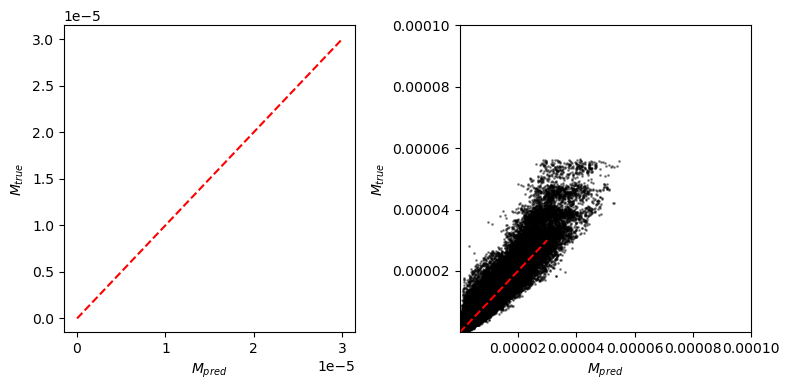

In [25]:
xs, ys = np.linspace(0., 3e-5, 1000), np.linspace(0., 3e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4), tight_layout=True)
# ax[0].scatter(linear_prediction_full.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
# ax[0].set_yscale("log")
# ax[0].set_xscale("log")

ax[1].scatter(fcnn_prediction_full.detach().numpy(), 10**y, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
# ax[1].set_yscale("log")
# ax[1].set_xscale("log")
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
ax[1].set_xlim(1e-10,1e-4)
ax[1].set_ylim(1e-10,1e-4)

# plt.savefig("inst_M_true_pred_with_utau.png", dpi=300)

In [25]:
fcnn_val_diff = fcnn_val_prediction_full.detach().numpy()[1:] - fcnn_val_prediction_full.detach().numpy()[:-1]
y_val_diff = 10**y_val[1:] - 10**y_val[:-1]

Text(0.5, 0, '$M_{pred}$')

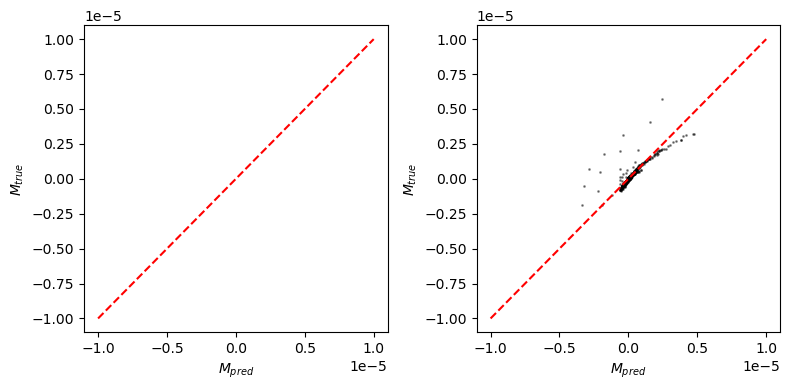

In [26]:
xs, ys = np.linspace(-1e-5, 1e-5, 1000), np.linspace(-1e-5, 1e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4), tight_layout=True)
# ax[0].scatter(linear_prediction_full.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
# ax[0].set_yscale("log")
# ax[0].set_xscale("log")

ax[1].scatter(fcnn_val_diff, y_val_diff, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
# ax[1].set_yscale("log")
# ax[1].set_xscale("log")
# ax[1].set_xscale("log")
# ax[1].set_yscale("log")
# ax[1].set_xlim(1e-10,1e-3)
# ax[1].set_ylim(1e-10,1e-3)

# plt.savefig("inst_M_true_pred_with_utau.png", dpi=300)

(-0.4, 0.4)

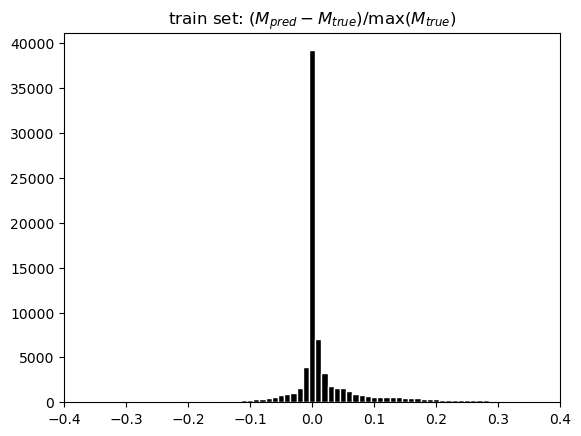

In [73]:
plt.hist((fcnn_prediction_full.detach().numpy()-y.detach().numpy())/y.mean().detach().numpy(), np.arange(-0.405,0.425,0.01), color="black", ec="white");
plt.title("train set: $(M_{pred}-M_{true})/\max(M_{true})$");
plt.xlim(-0.4,0.4)

(-0.4, 0.4)

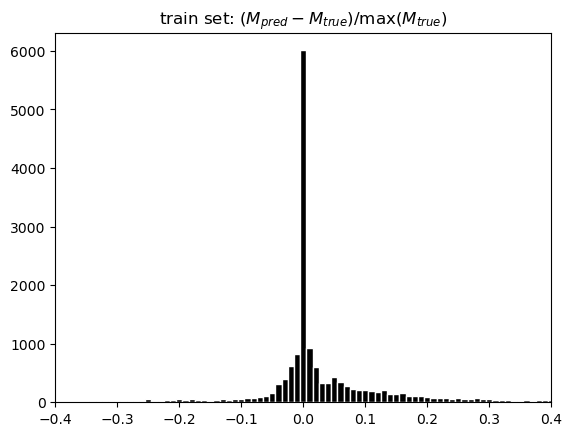

In [74]:
plt.hist((fcnn_val_prediction_full.detach().numpy()-y_val.detach().numpy())/y.mean().detach().numpy(), np.arange(-0.405,0.425,0.01), color="black", ec="white");
plt.title("train set: $(M_{pred}-M_{true})/\max(M_{true})$");
plt.xlim(-0.4,0.4)

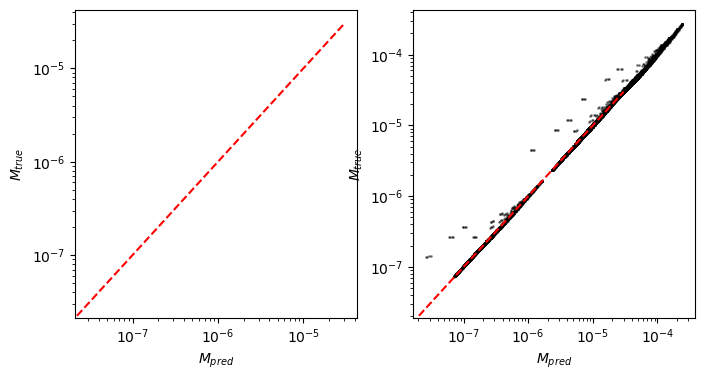

In [42]:
xs, ys = np.linspace(0., 3e-5, 1000), np.linspace(0., 3e-5, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4))
# ax[0].scatter(linear_val_prediction_full.detach().numpy(), y_val, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
ax[0].set_yscale("log")
ax[0].set_xscale("log")

ax[1].scatter(fcnn_val_prediction_full.detach().numpy(), y_val, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
ax[1].set_yscale("log")
ax[1].set_xscale("log")

/tmp/ipykernel_1104122/3343130403.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


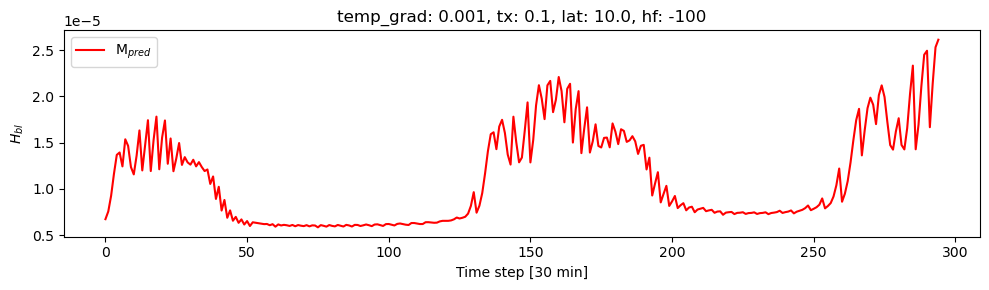

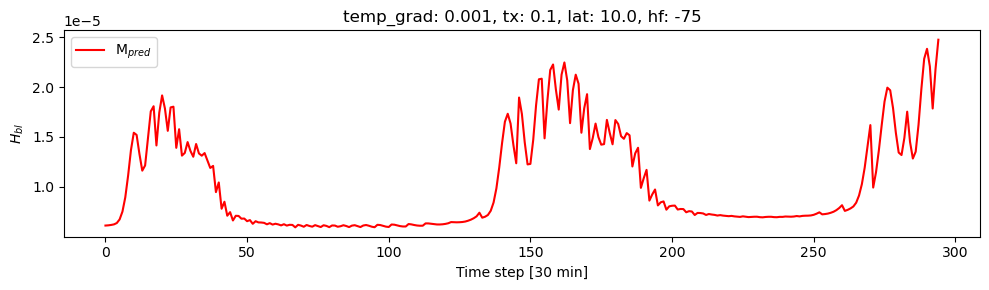

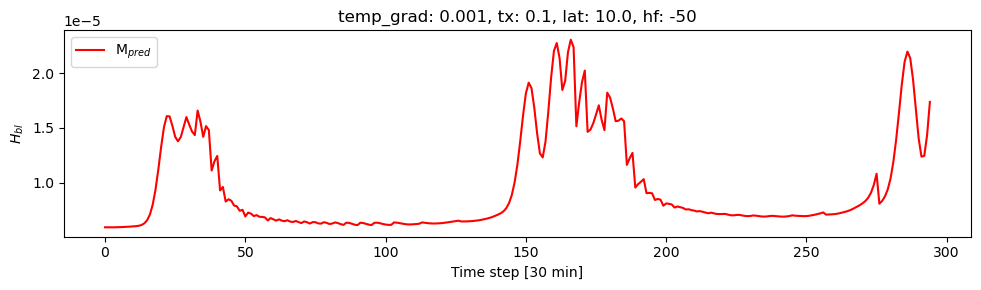

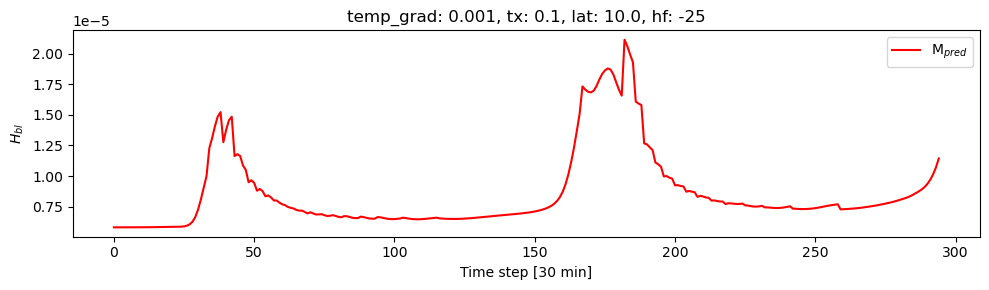

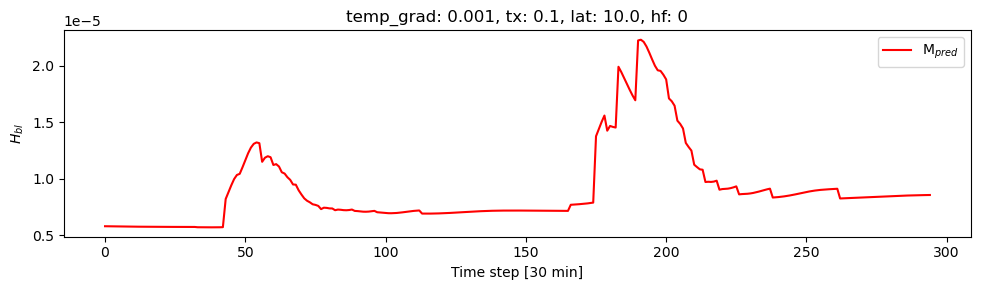

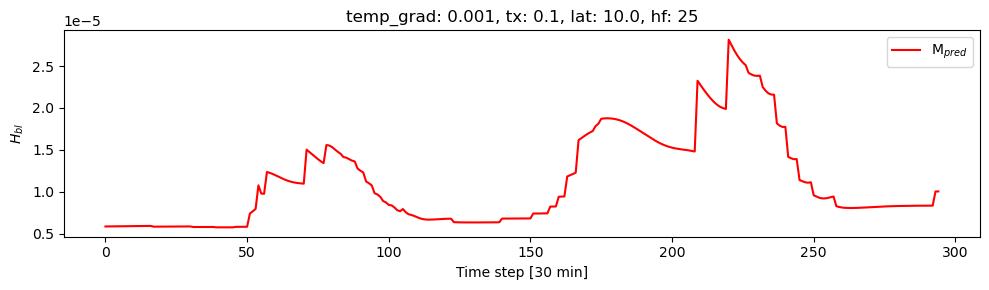

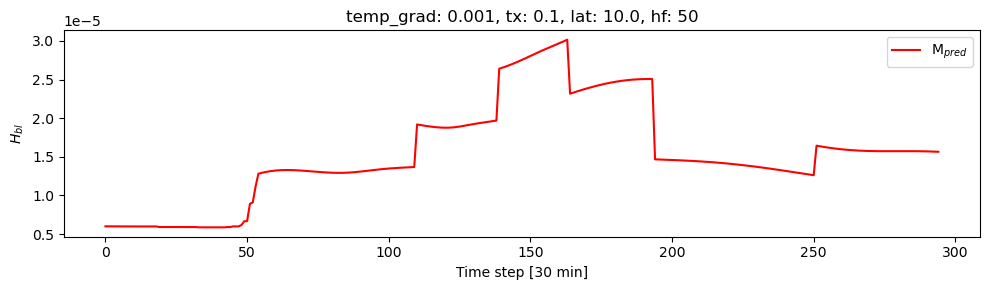

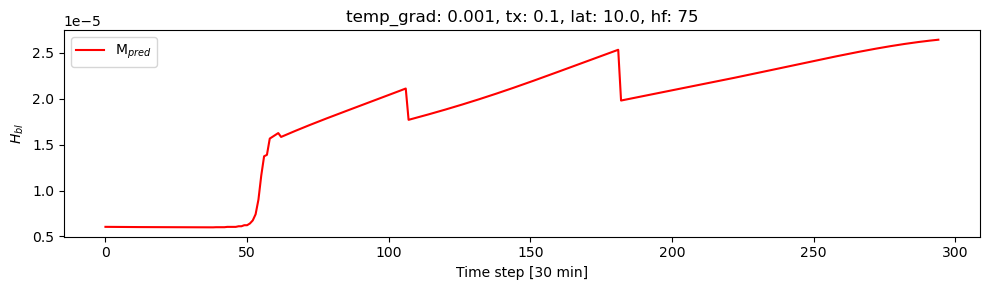

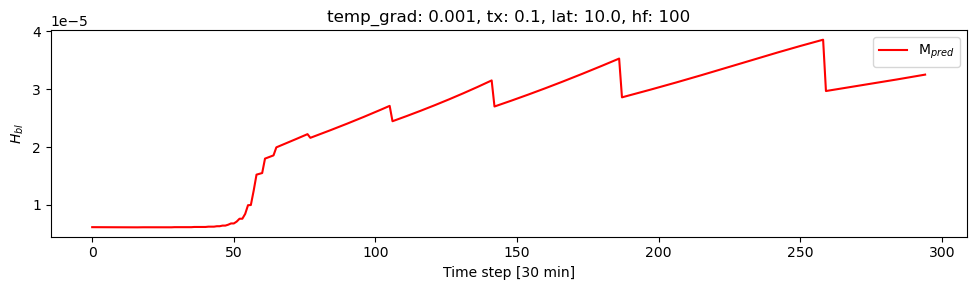

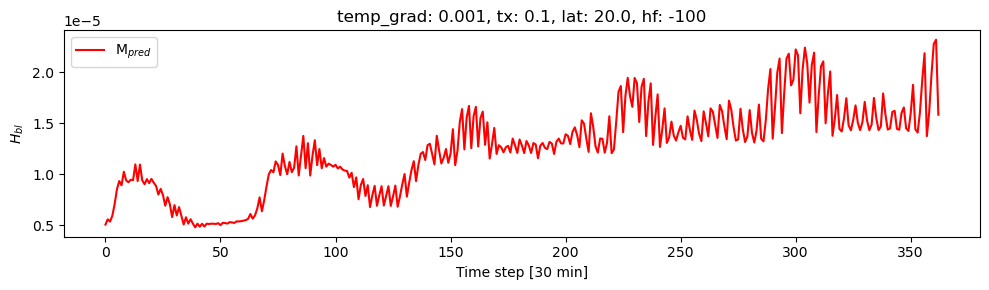

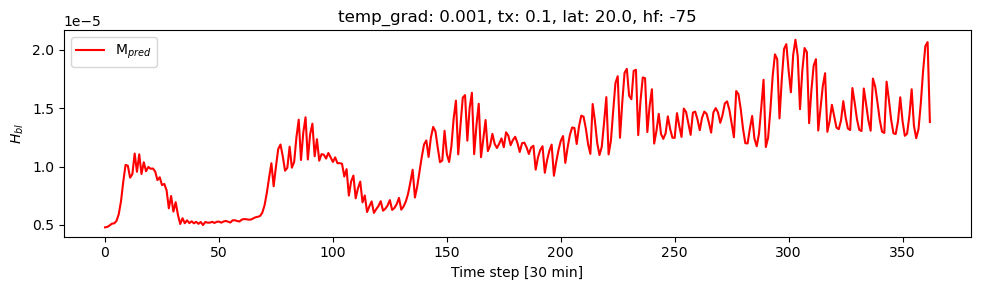

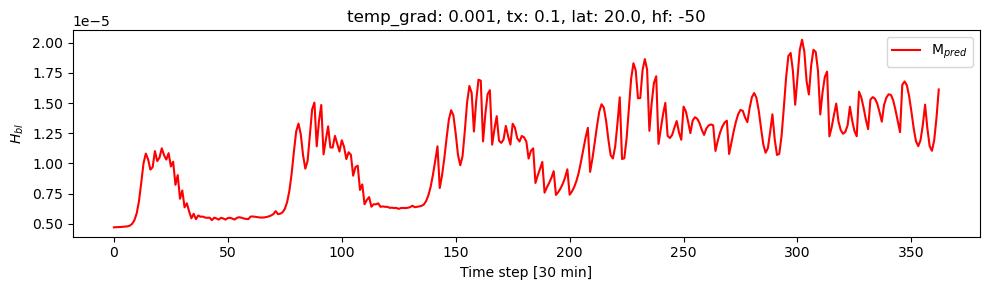

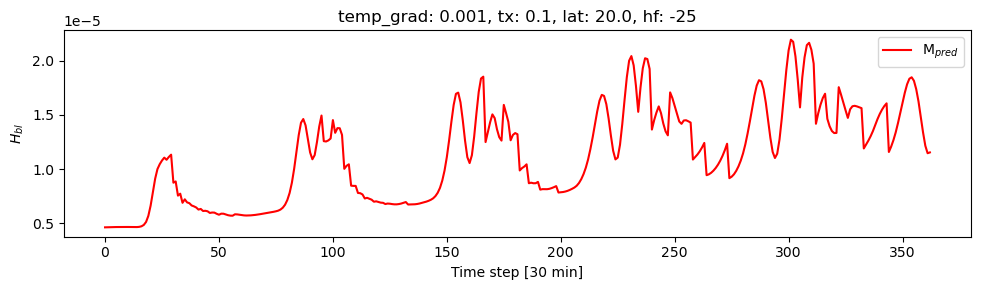

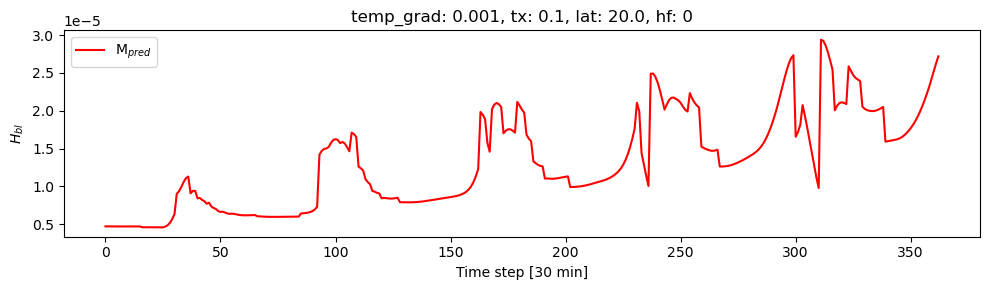

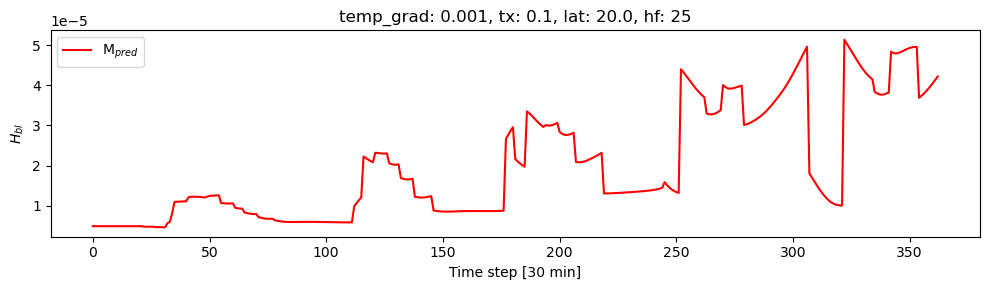

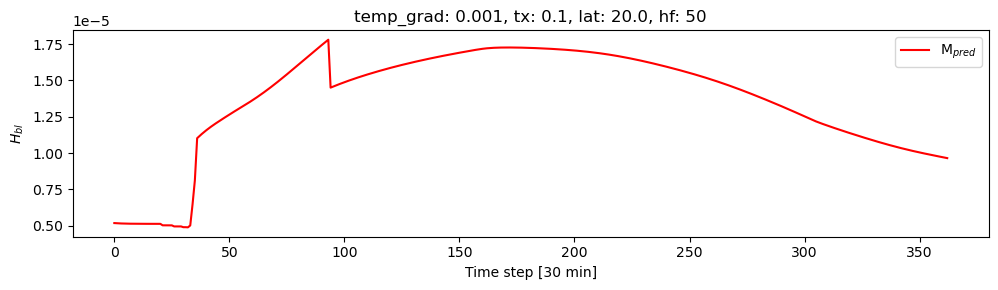

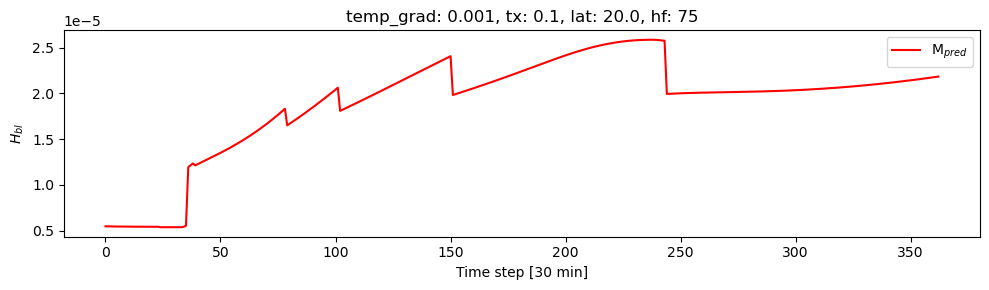

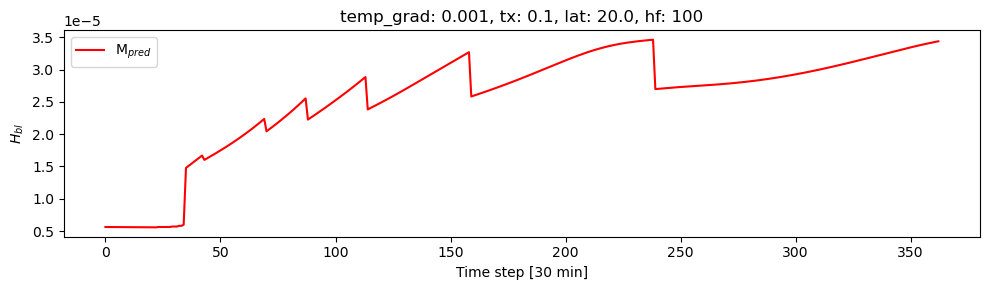

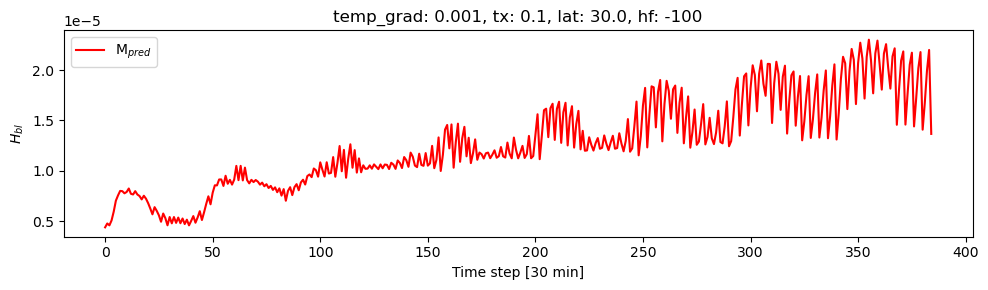

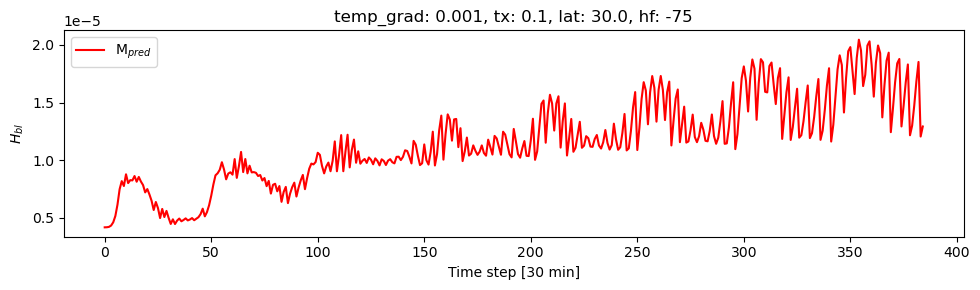

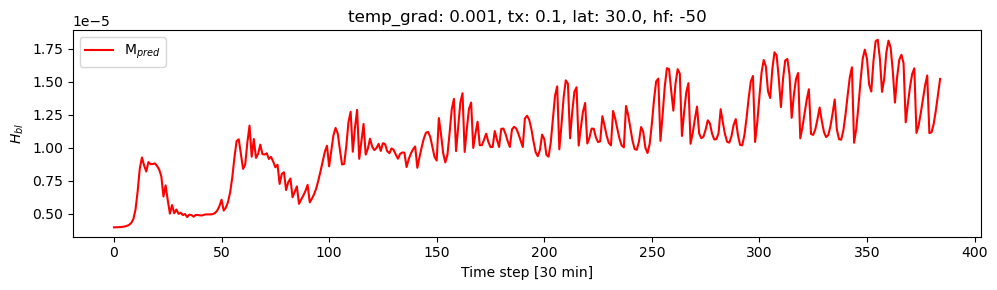

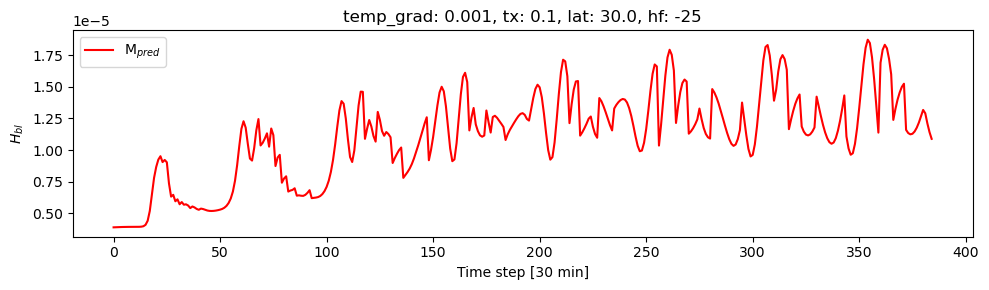

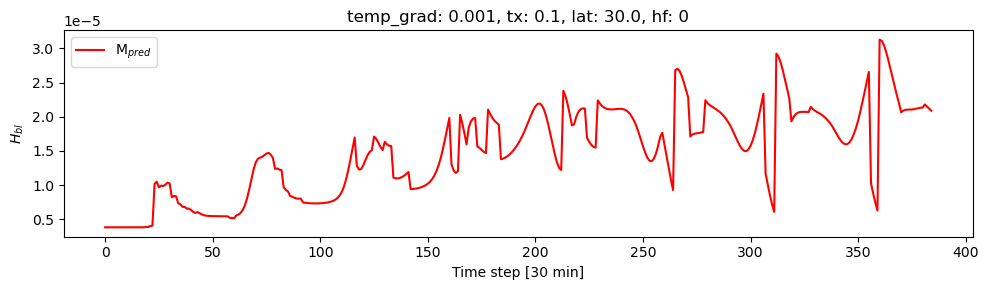

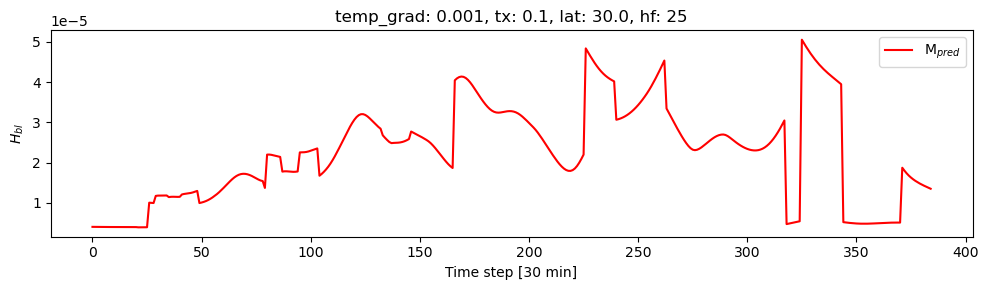

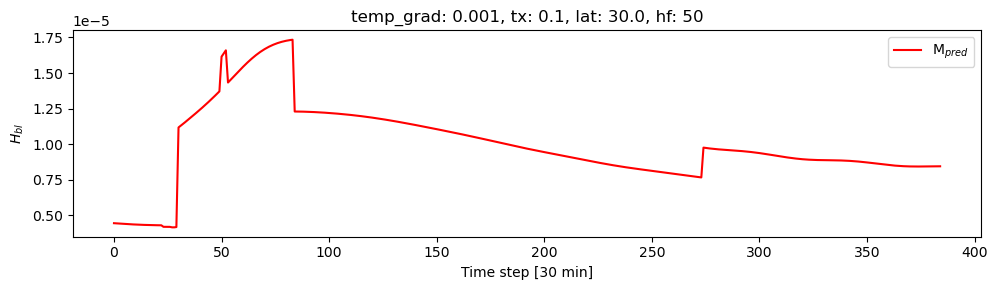

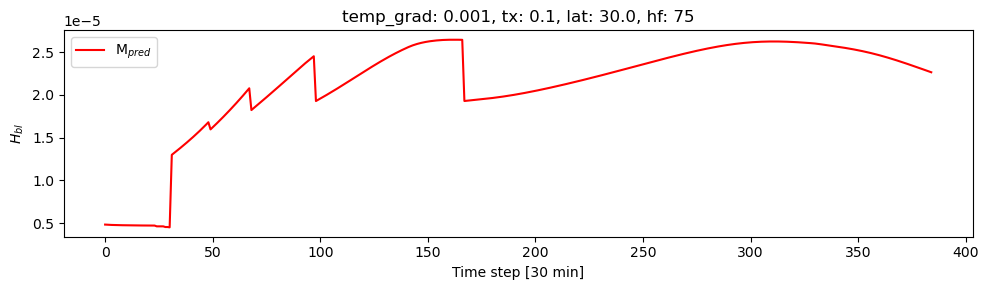

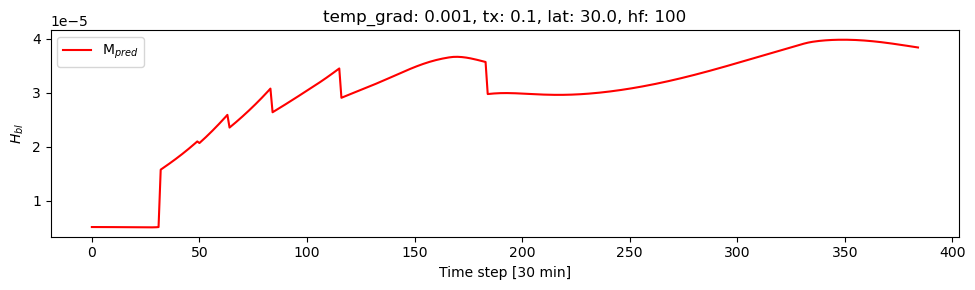

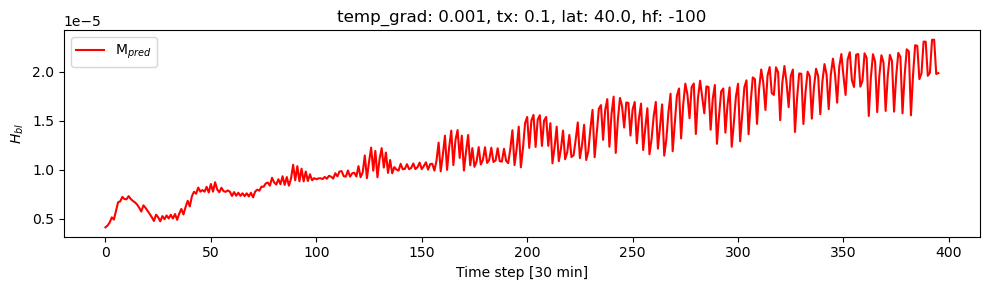

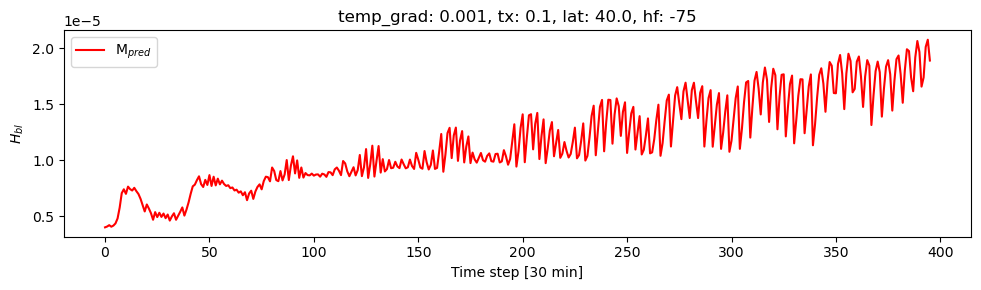

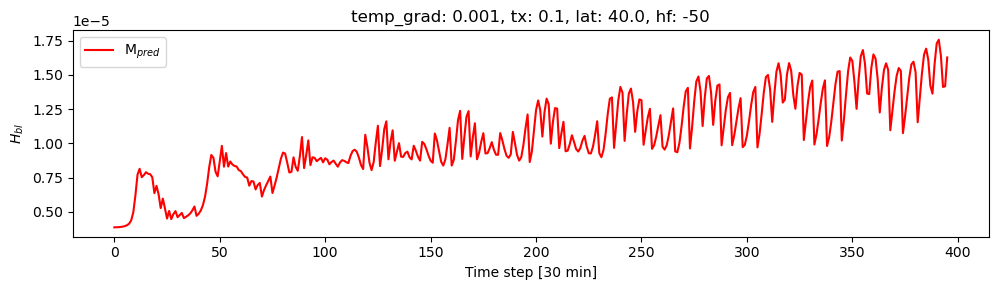

In [73]:
current_timestep = 0

for i in range(30):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(X.detach().numpy()[current_timestep:current_timestep+n_timesteps[i],7], label="M$_{pred}$", color="red")
    # plt.plot(y[n_timesteps*i:n_timesteps*(i+1)], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("$H_{bl}$")
    plt.legend()
    current_timestep += n_timesteps[i]

In [25]:
start, end = 400, 430
current_timestep = sum(n_timesteps[:start])

for i in range(start, end):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_full.detach().numpy()[current_timestep:current_timestep+n_timesteps[i]], label="M$_{pred}$", color="red")
    plt.plot(y[current_timestep:current_timestep+n_timesteps[i]], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()
    current_timestep += n_timesteps[i]

NameError: name 'n_timesteps' is not defined

In [24]:
start, end = 90, 120
current_timestep = sum(n_timesteps_val[:start])

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_val_prediction_full.detach().numpy()[current_timestep:current_timestep+n_timesteps_val[i]], label="M$_{pred}$", color="red")
    plt.plot(y_val[current_timestep:current_timestep+n_timesteps_val[i]], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()
    current_timestep += n_timesteps_val[i]

TypeError: 'int' object is not subscriptable

/tmp/ipykernel_453549/1782494431.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


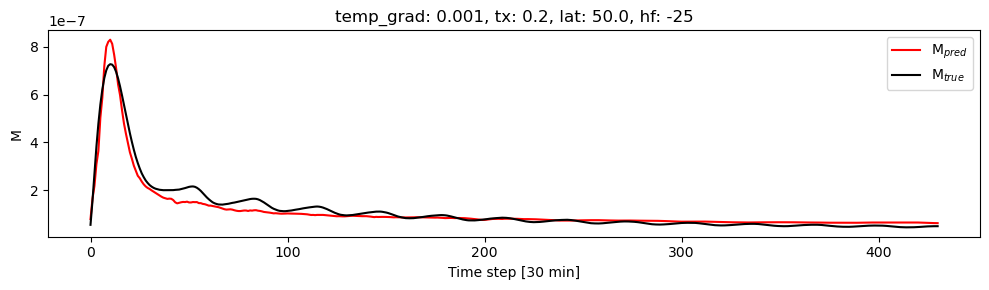

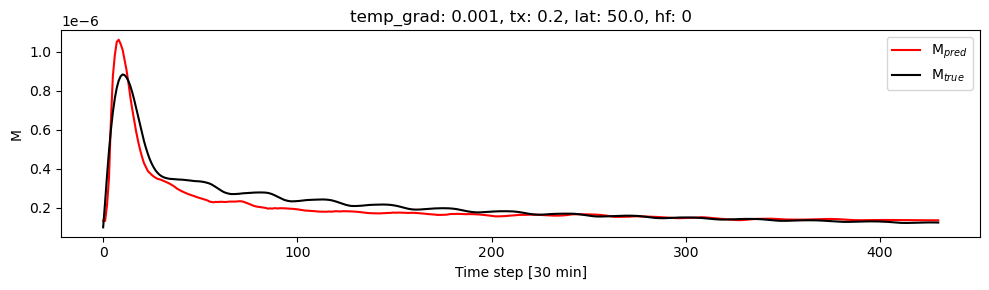

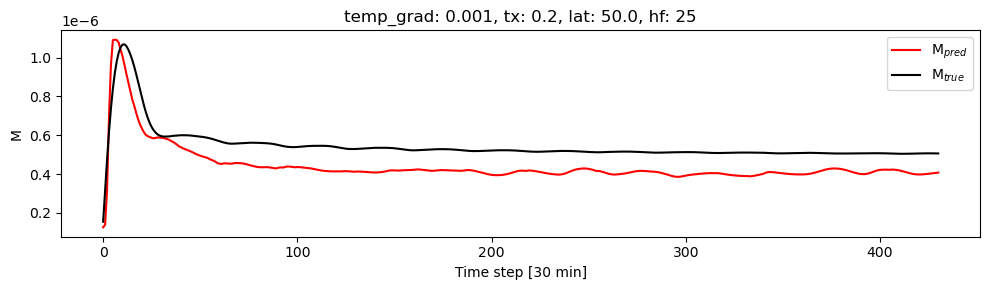

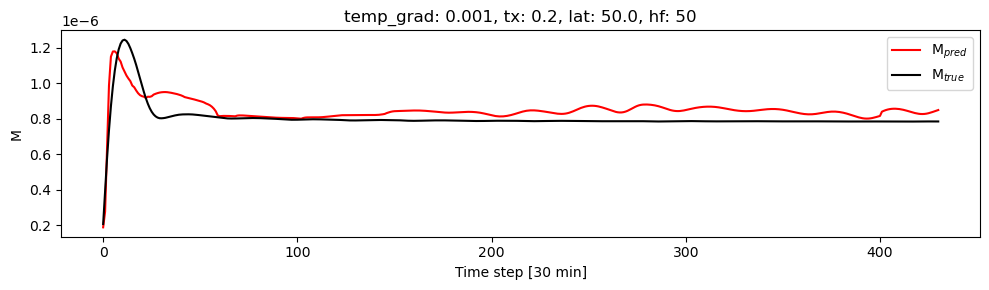

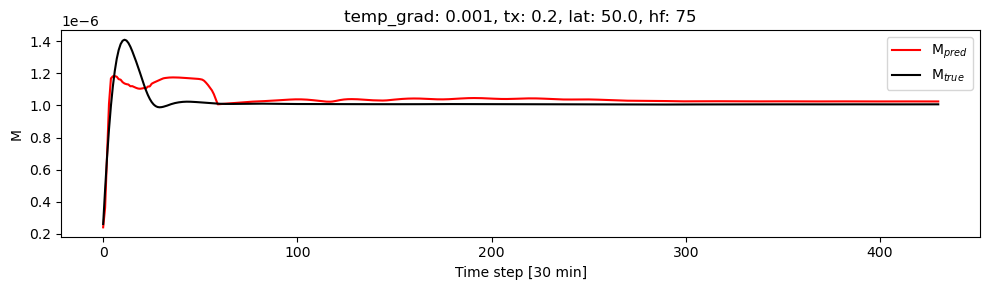

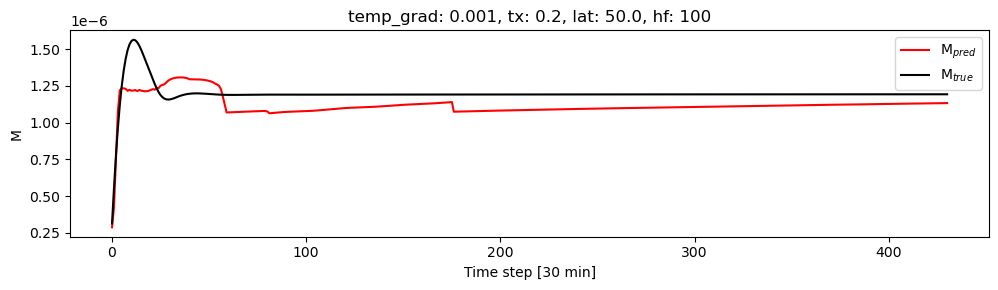

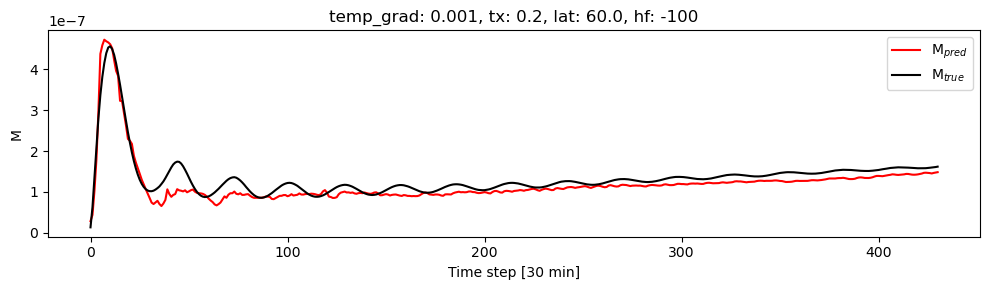

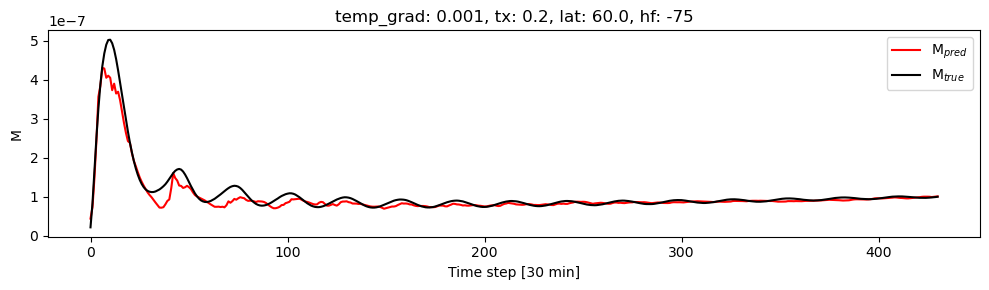

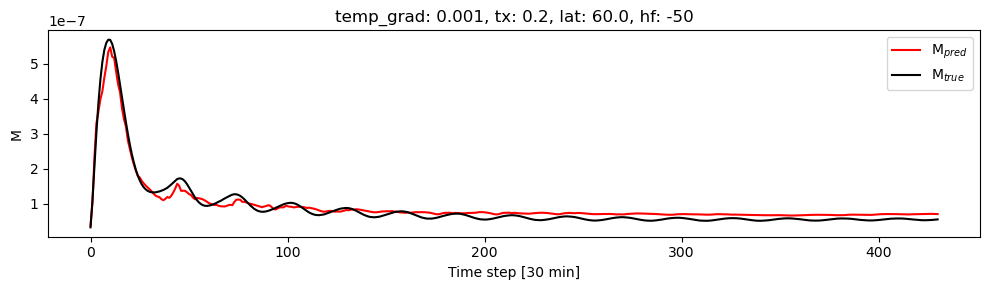

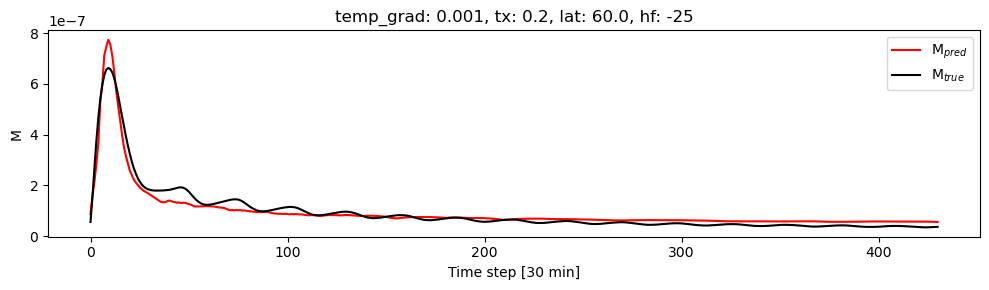

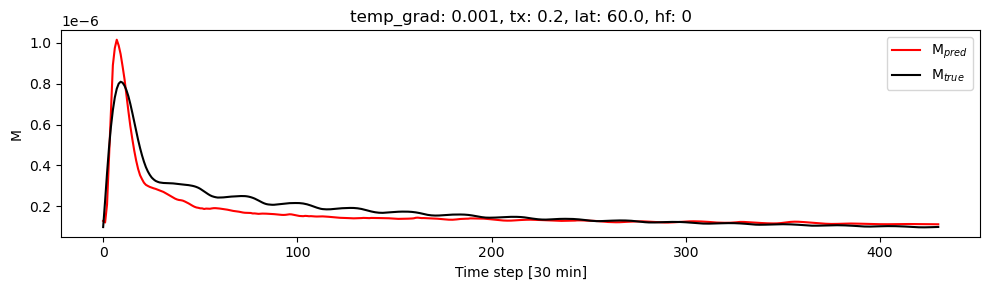

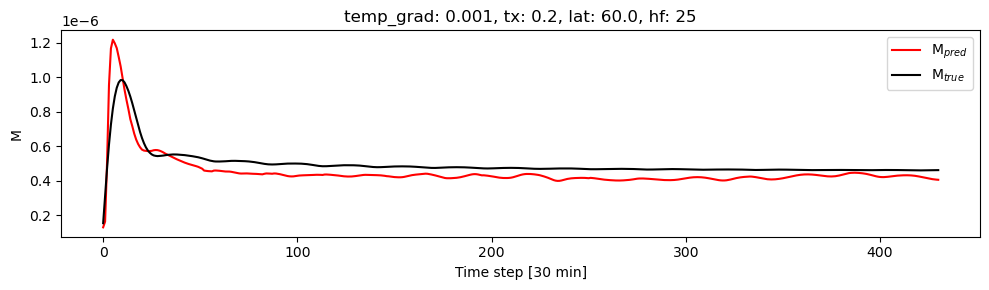

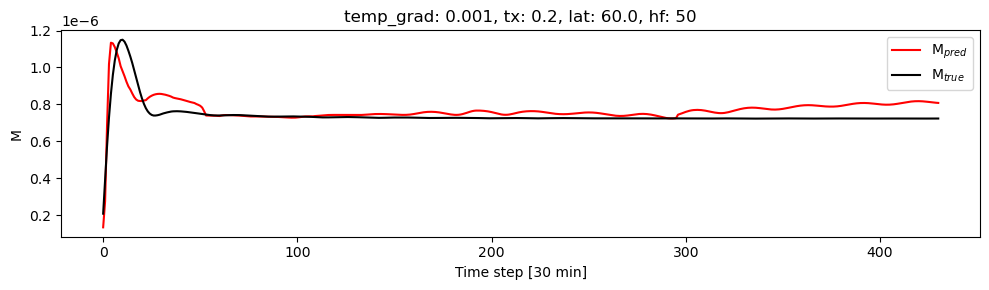

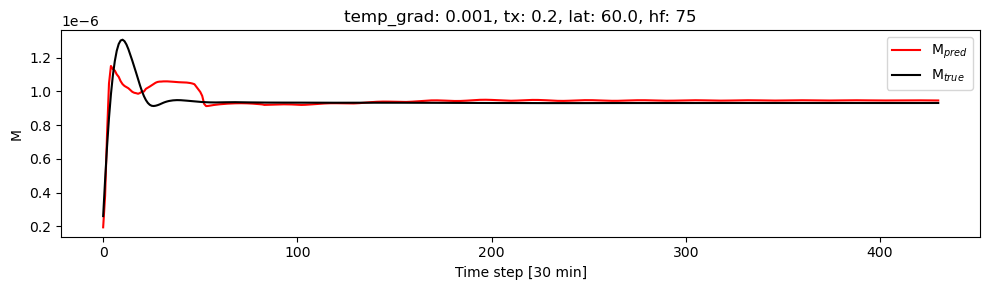

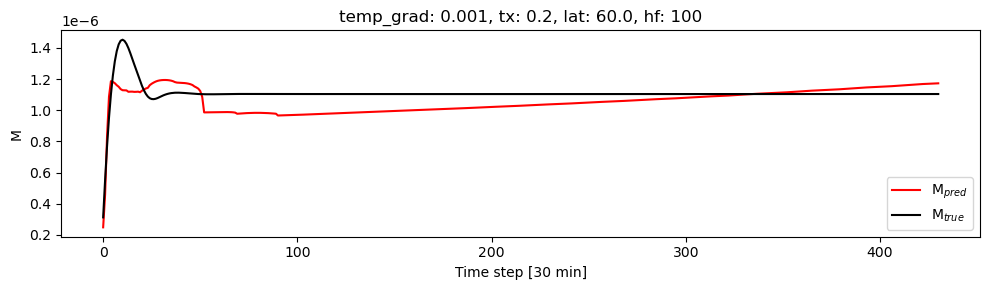

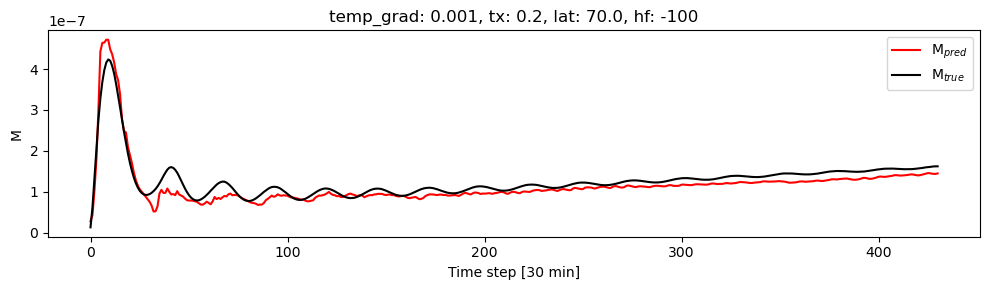

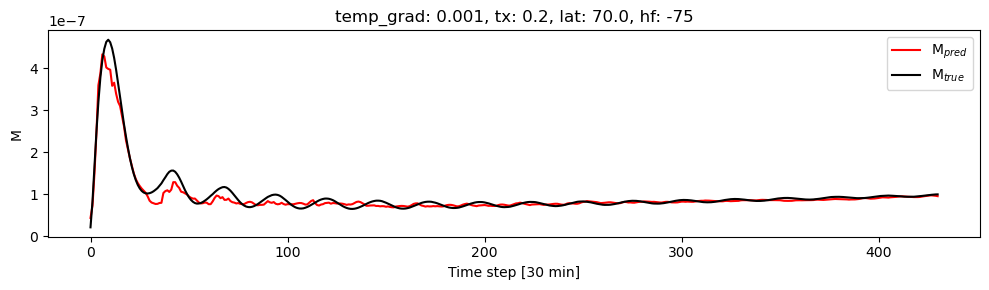

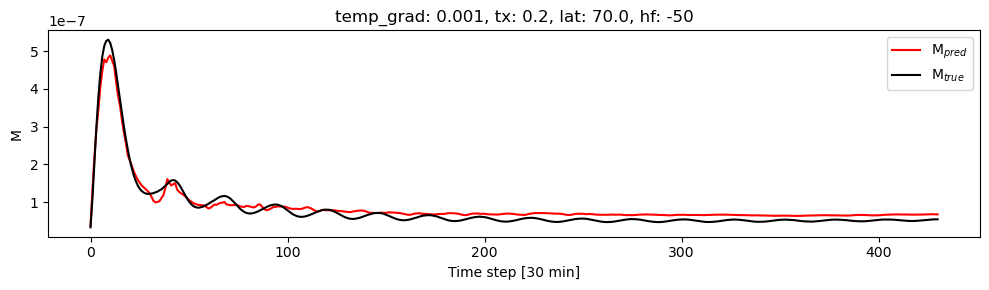

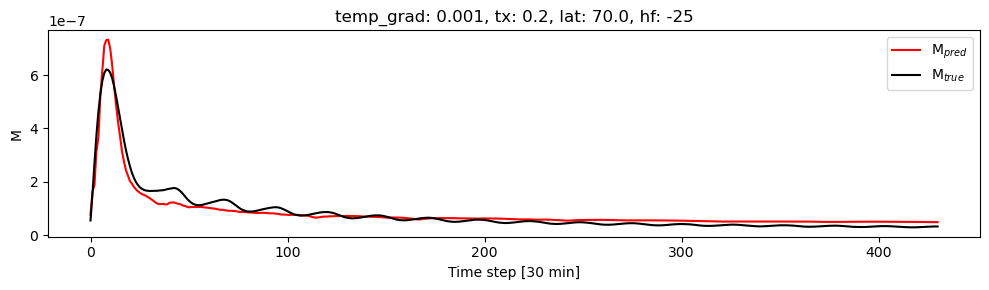

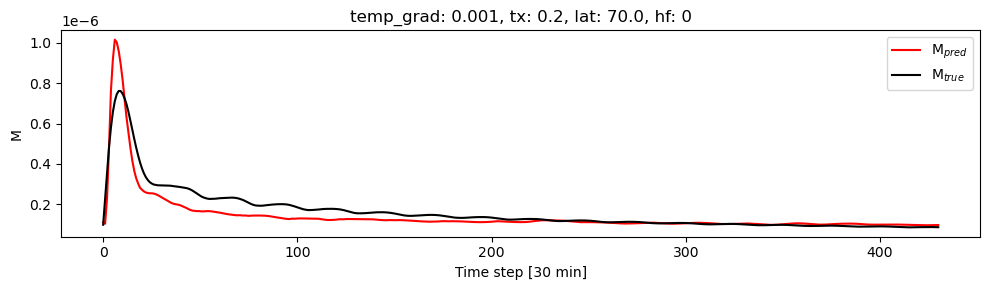

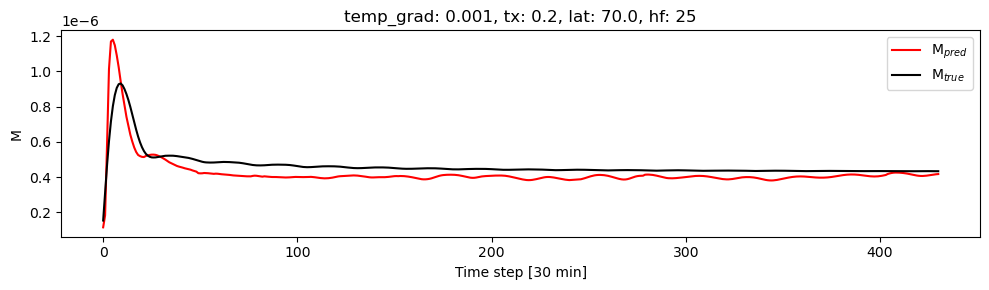

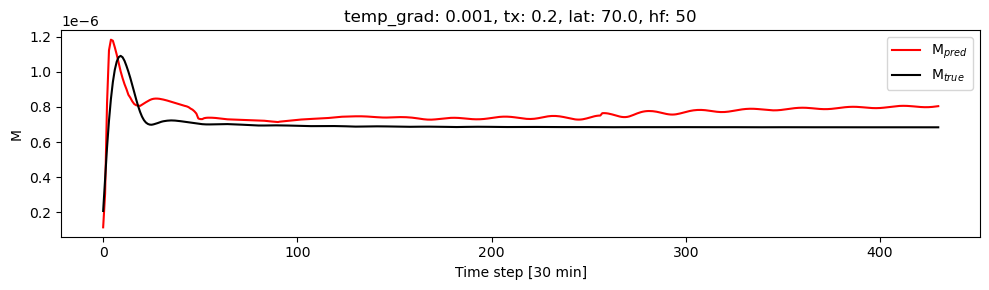

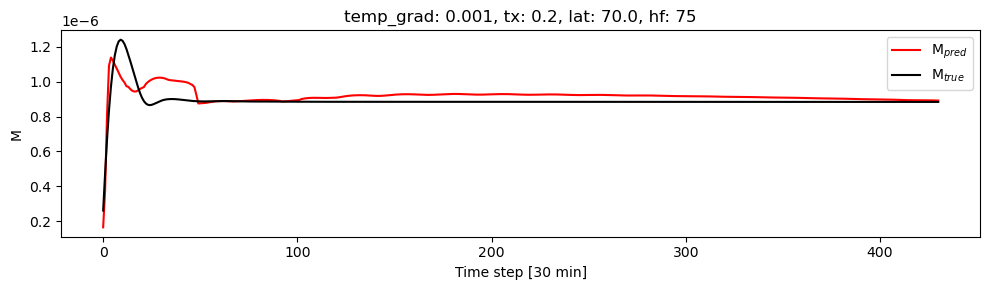

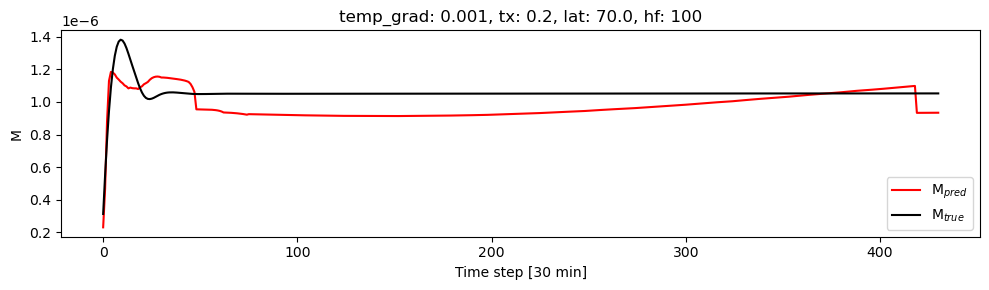

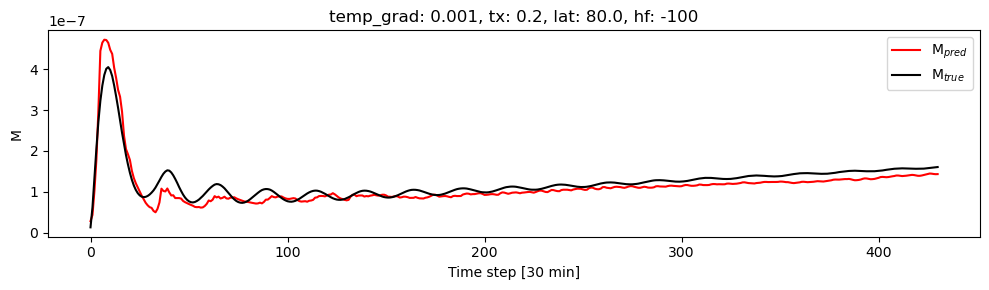

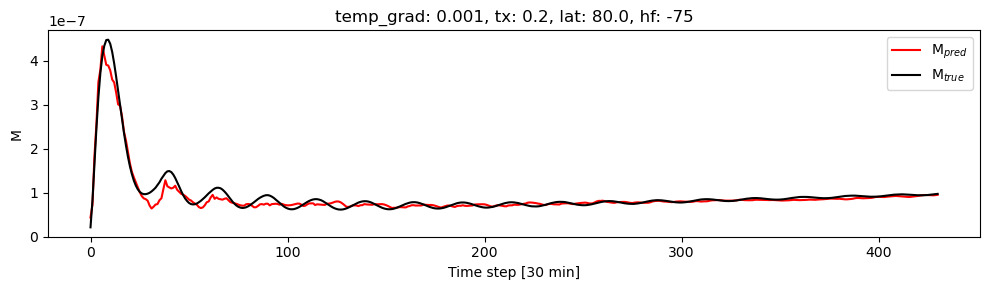

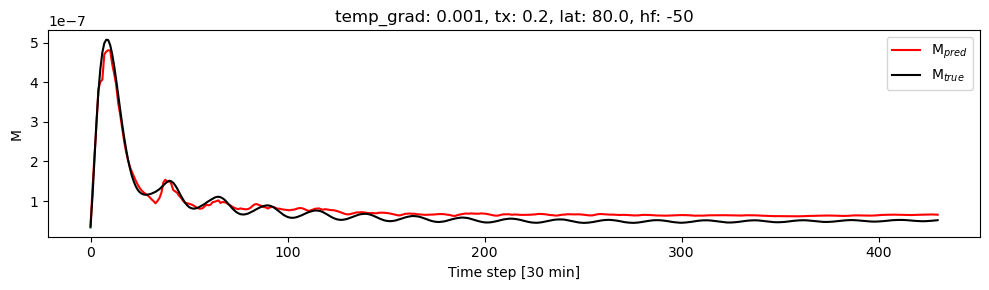

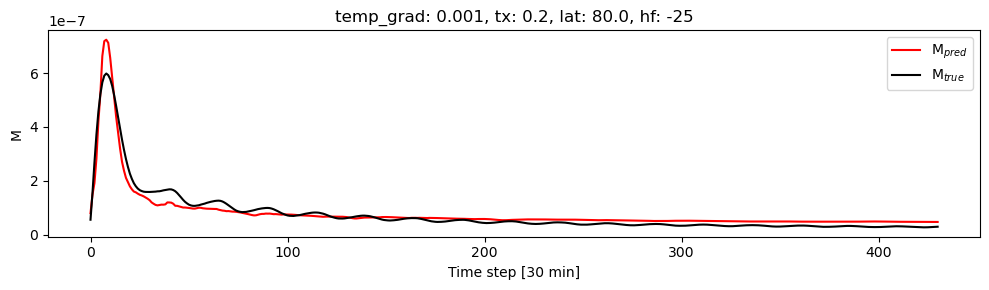

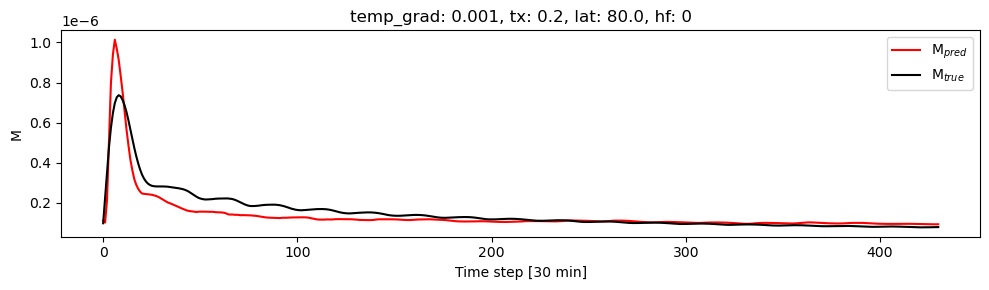

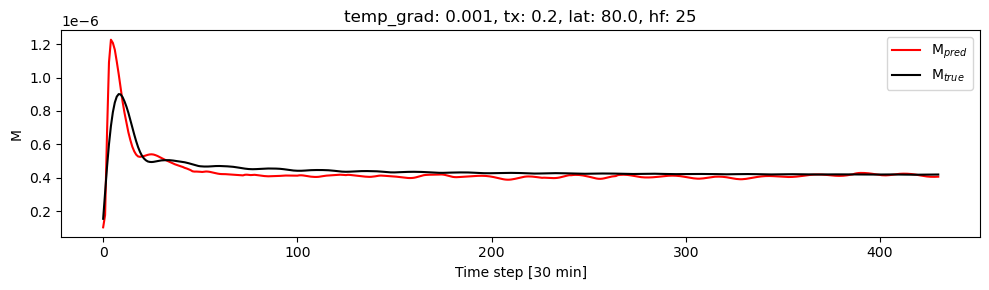

In [36]:
start, end = 120, 150
n_timesteps = 431

for i in range(start,end):
    case_specs = gotm_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_prediction_full.detach().numpy()[n_timesteps*i:n_timesteps*(i+1)], label="M$_{pred}$", color="red")
    plt.plot(10**y[n_timesteps*i:n_timesteps*(i+1)], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()

/tmp/ipykernel_1010336/3651926565.py:7: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure(tight_layout=True, figsize=(10,3))


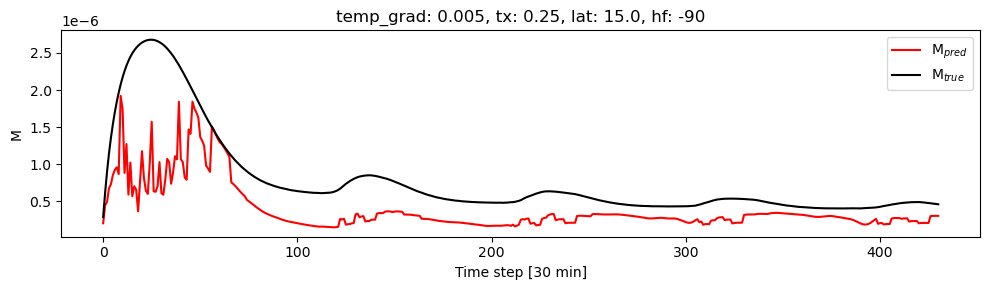

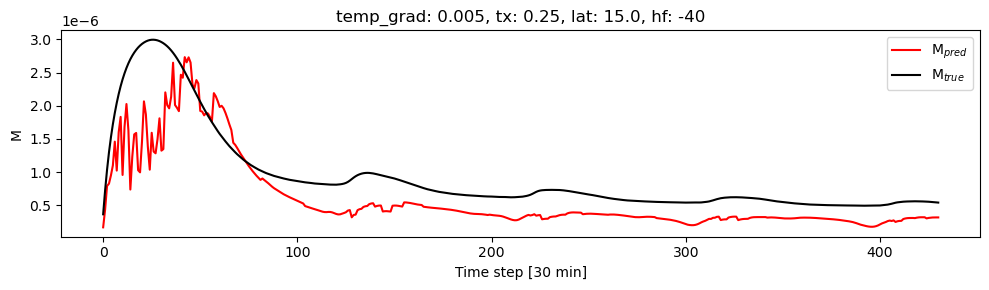

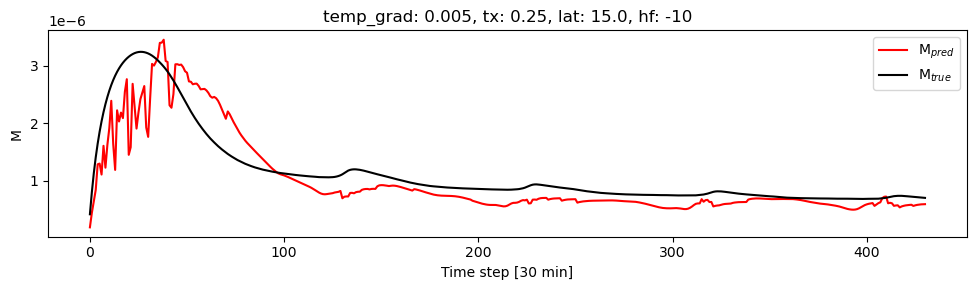

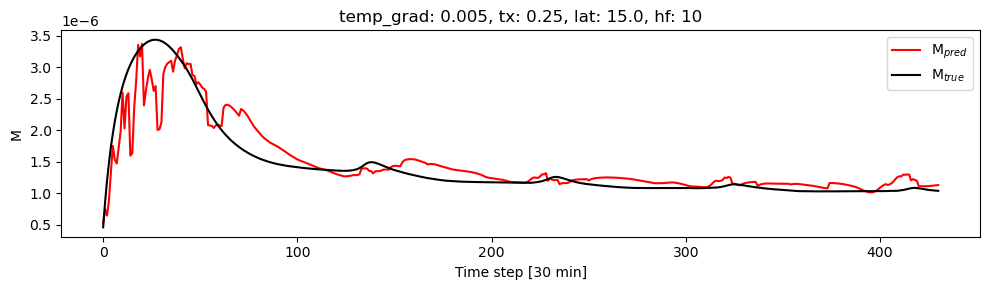

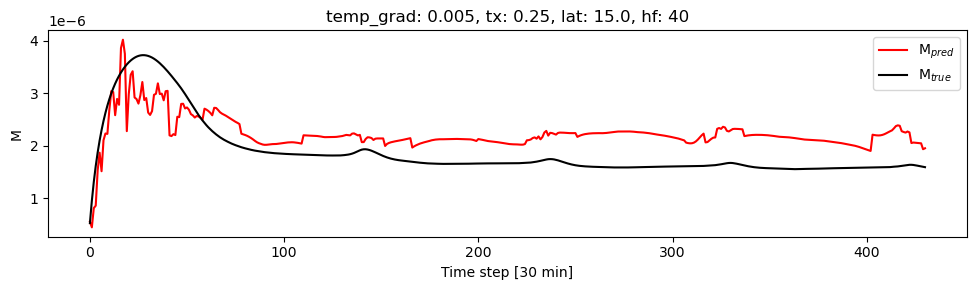

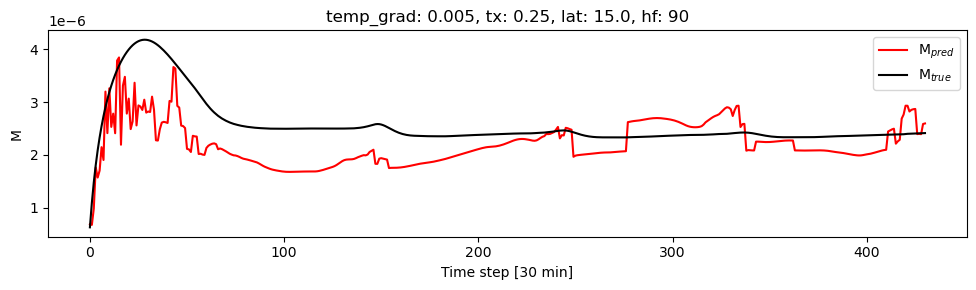

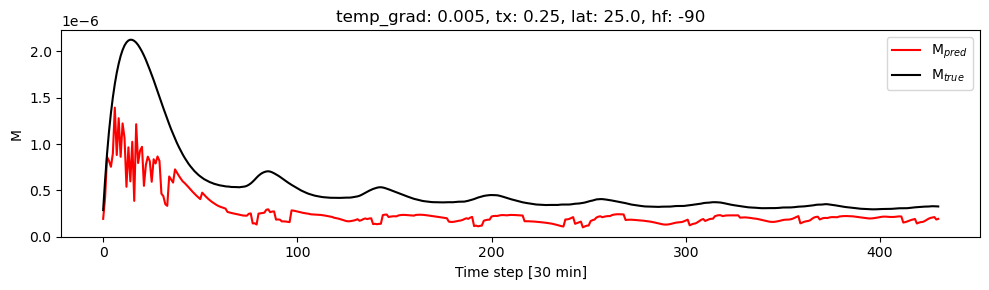

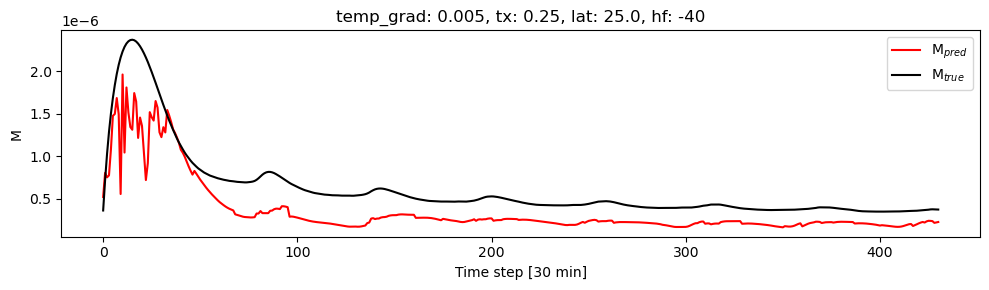

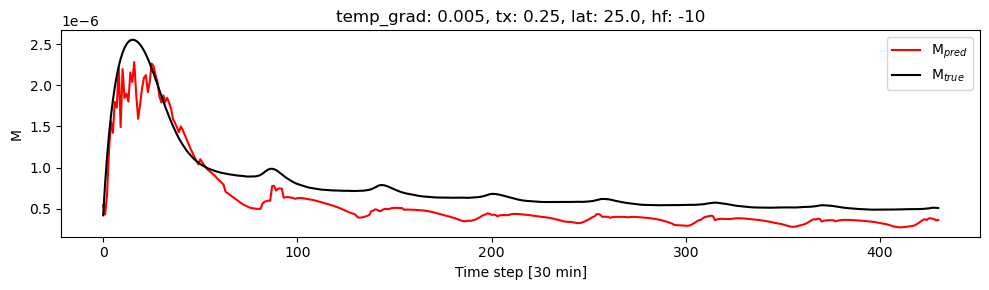

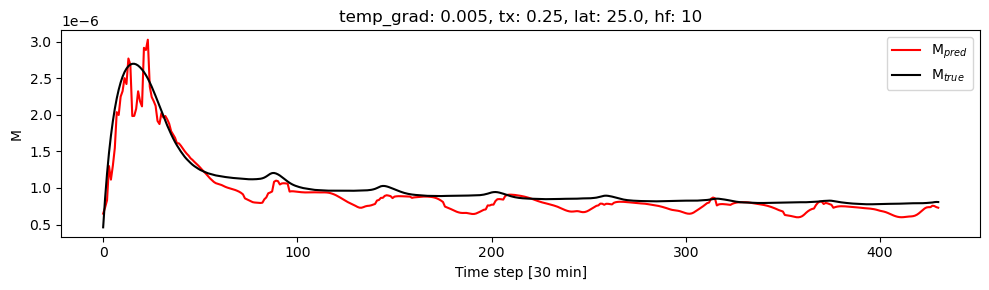

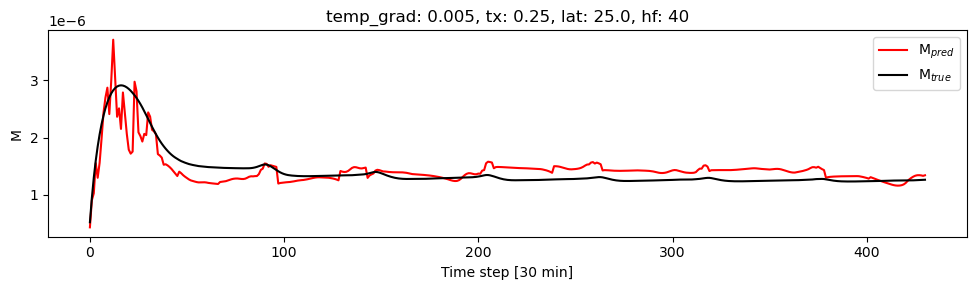

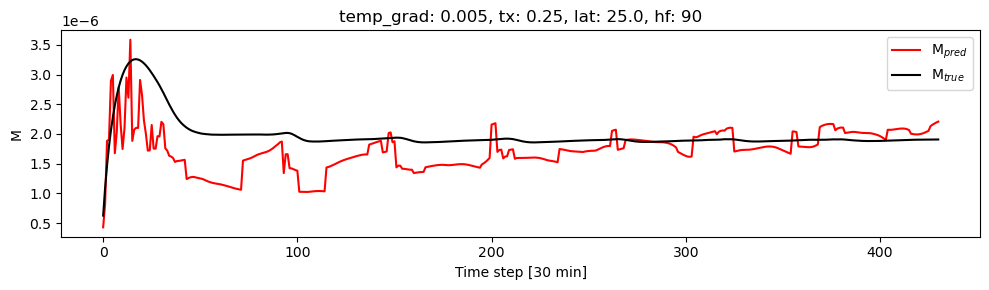

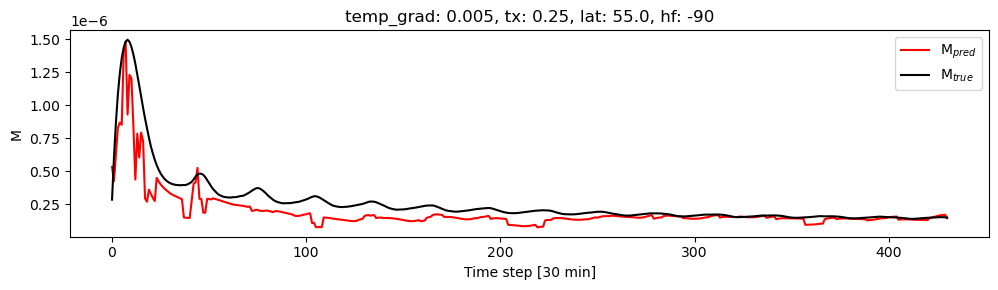

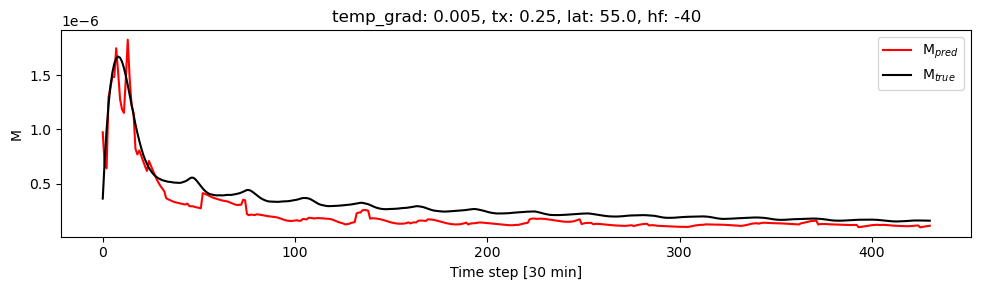

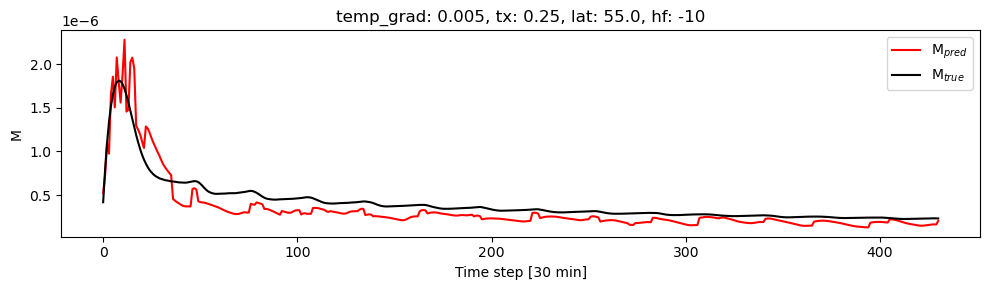

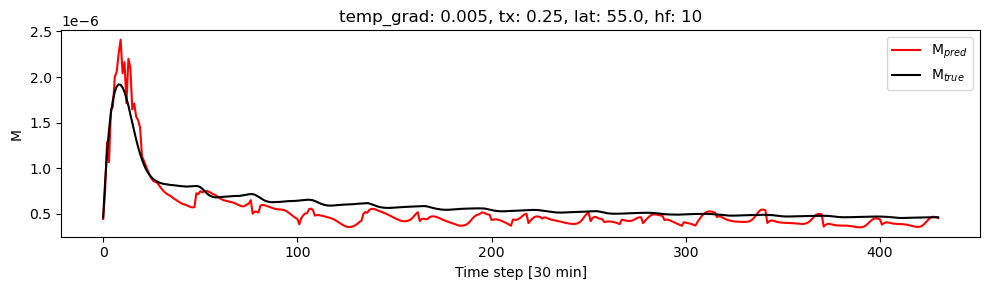

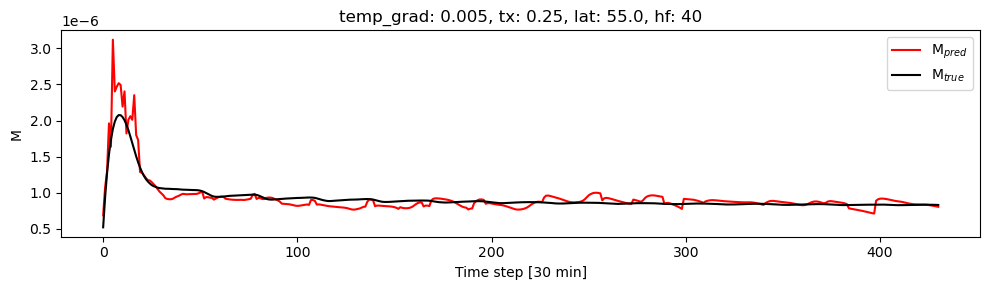

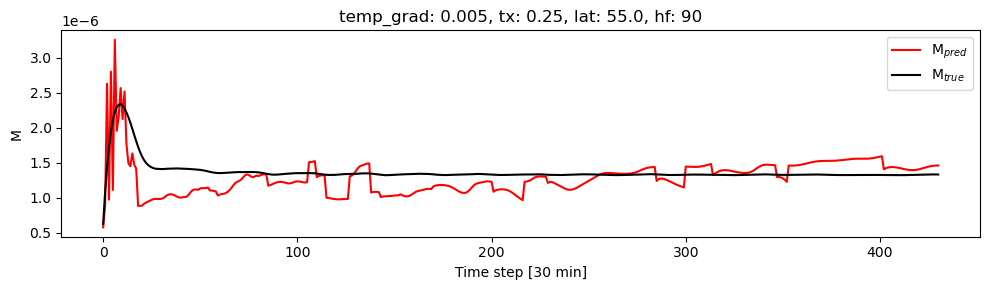

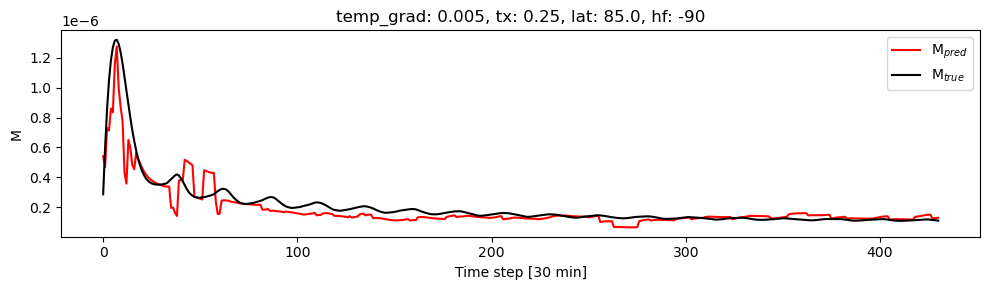

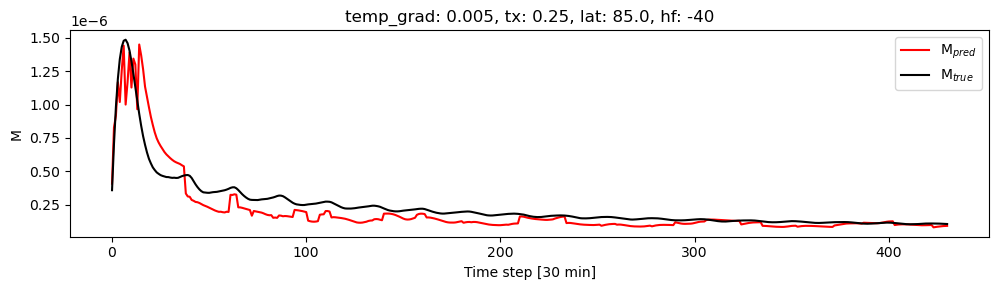

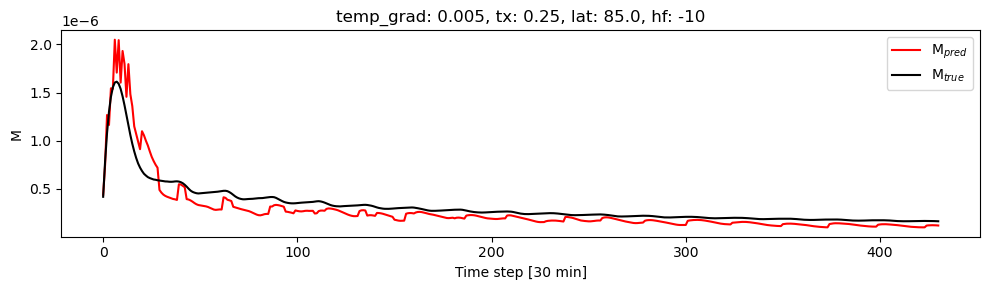

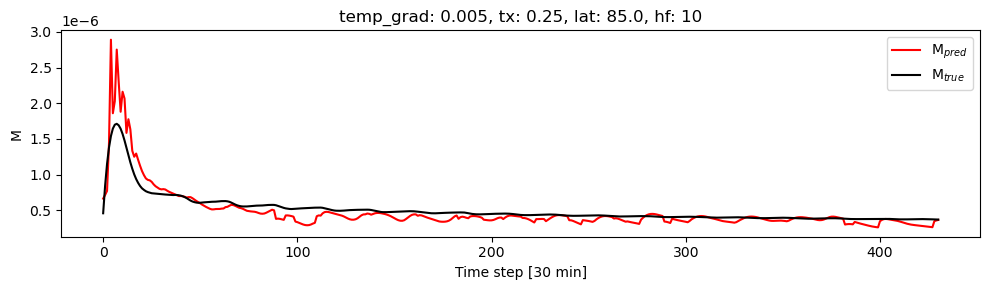

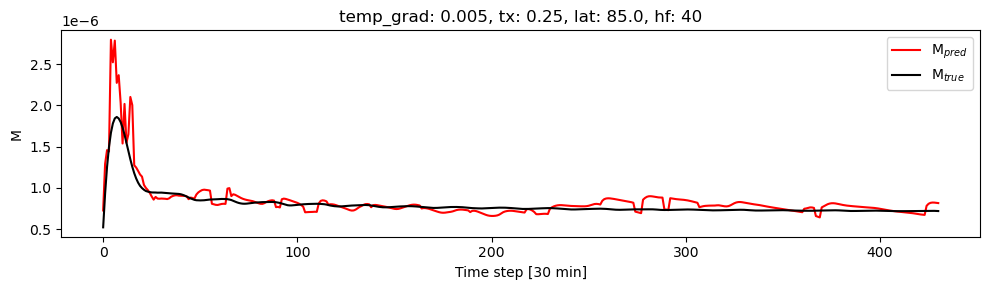

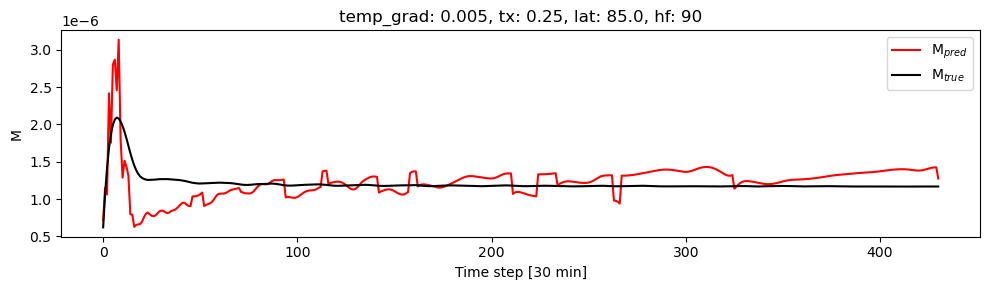

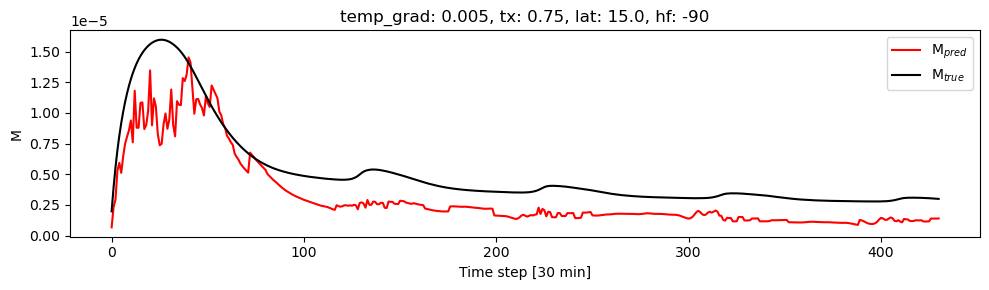

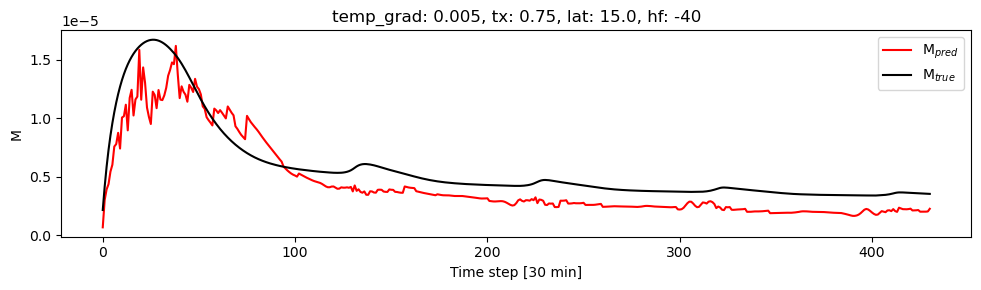

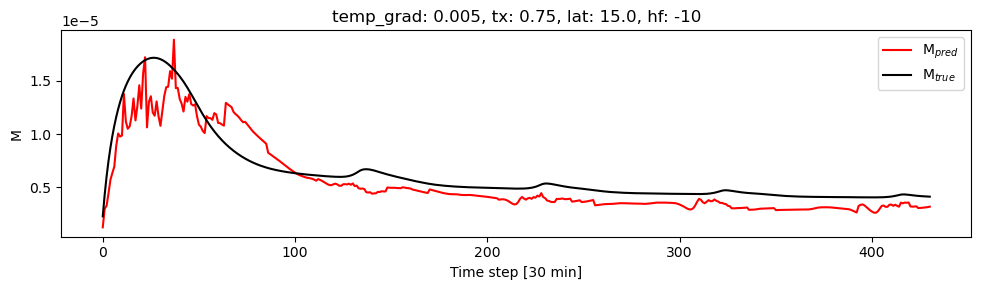

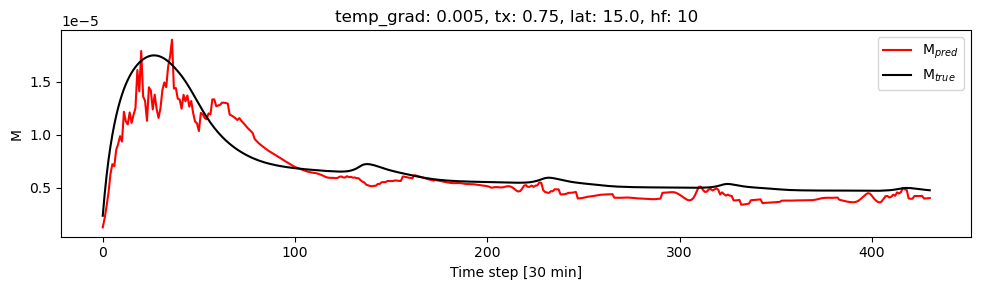

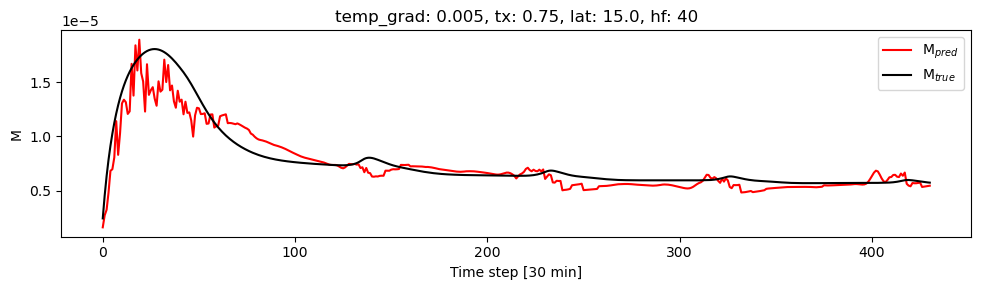

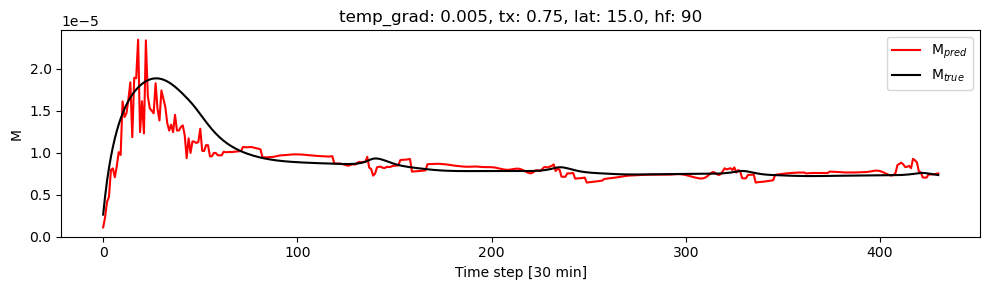

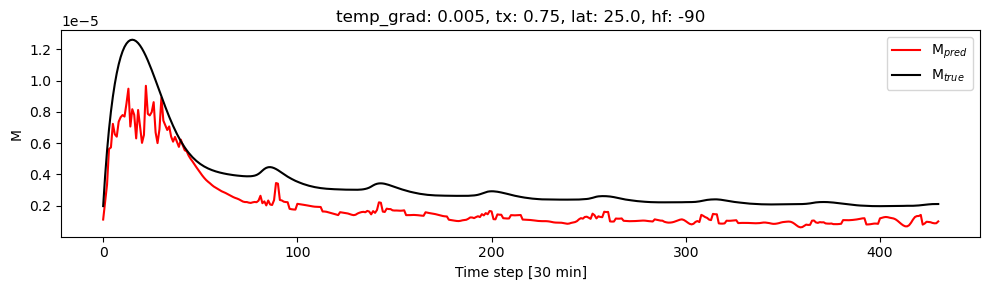

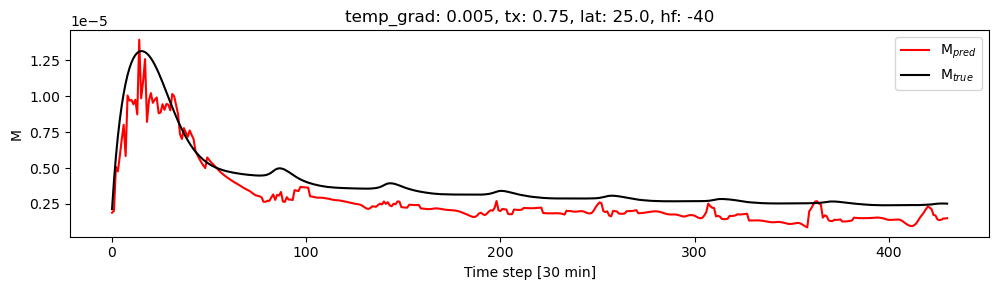

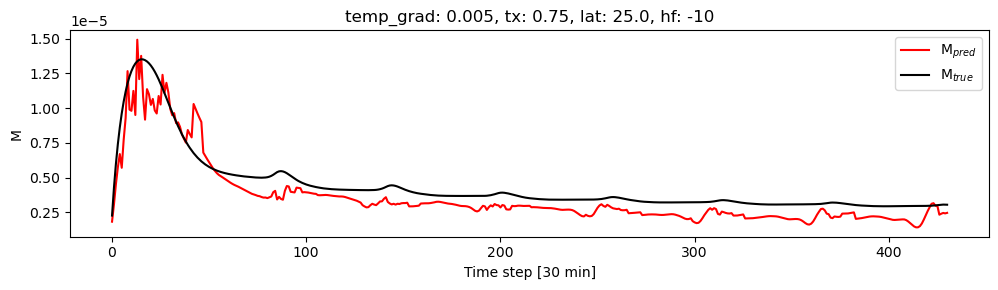

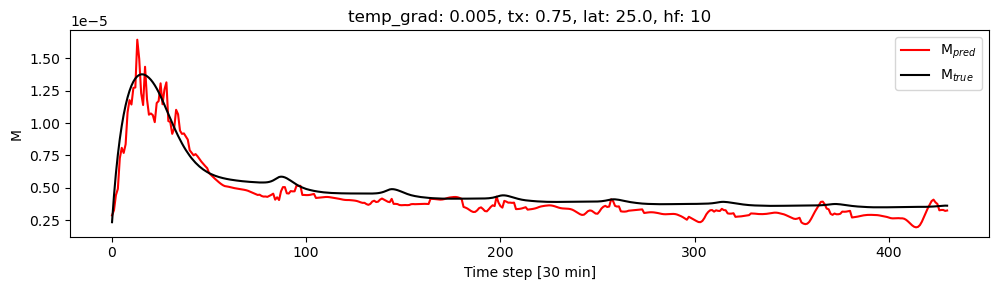

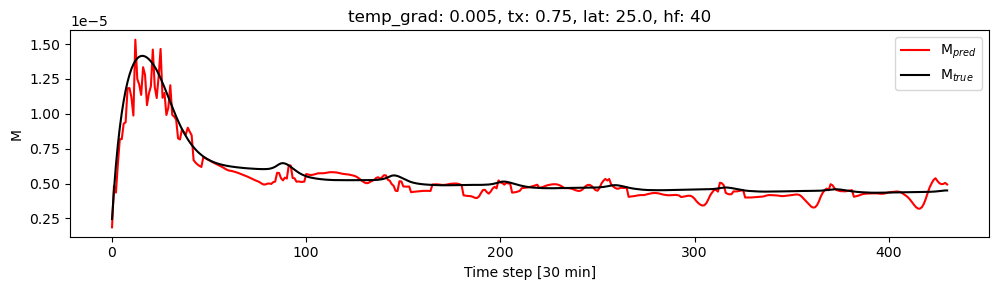

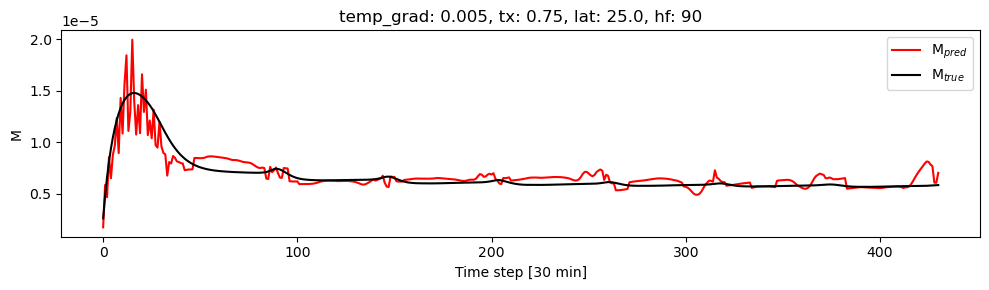

In [26]:
start, end = 0, 36
n_timesteps = 431

for i in range(start, end):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    plt.figure(tight_layout=True, figsize=(10,3))
    plt.title(f"temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    plt.plot(fcnn_val_prediction_full.detach().numpy()[n_timesteps*i:n_timesteps*(i+1)], label="M$_{pred}$", color="red")
    plt.plot(10**y_val[n_timesteps*i:n_timesteps*(i+1)], label="M$_{true}$", color="black")
    plt.xlabel("Time step [30 min]")
    plt.ylabel("M")
    plt.legend()

In [25]:
compute_rmse(y_pred=fcnn_val_prediction_full, y_true=y_val)

tensor(5.1554e-06, grad_fn=<SqrtBackward0>)

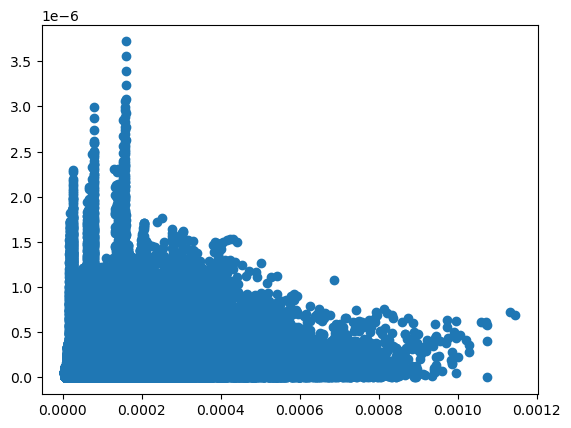

In [155]:
plt.scatter(X_val[:,10], (fcnn_val_prediction_full-y_val).abs().detach().numpy())